In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
import os
import gc
from tqdm import tqdm
import itertools as itt

import igraph as ig
import numpy as np
import pandas as pd
import torch as tc

from matplotlib import pyplot as plt
import seaborn as sns

import sys
sys.path.insert(0, '..') # TODO: this is probably not the right way to do this

from src.datasets import NetworksDataset, TEPsDataset
from src.automata import LLNA
#from src.analysis import jacobian, jacobian_ECA, calculate_Yt, lyapunov_spectrum

sns.set_palette('Set2')

In [3]:
sys.path.insert(0, '../src/network_analysis/lib') 
from analytics import DataPool, Report

datapool = DataPool()
datapool.load('../data/info', n=True, m=True, r=True)

../data/info/flags.dat loaded in memory
../data/info/networks.dat loaded in memory
../data/info/measures.dat loaded in memory
../data/info/results.dat loaded in memory


Trajectory difference depends on the original trajectory and its disturbed version. One way to study it it by disturbing once, at the begining (results in the dataset with `disturb_freq="single"`), another way is by perturbing the original trajectory multiple times, on every time step (`disturb_freq="multi"`).

If the disturb occurs only once, then each trajectory will evolve independly. The damage can spread (growing) of vanish (shrinking). The amount of damage in the configuration space generated by a single unitary defect is given by the divergence of the trajectories along time.

$$ \mathbf{x}^t = \Phi^t(\mathbf{x}^0) $$

$$ \Delta\mathbf{x}^t = \mathbf{x}^t \oplus \Phi^t(\mathbf{x}^0 \oplus \delta\mathbf{x}^0) $$

Another way to approach this problem is by disturbing the main trajectory at each time step to see how it is sensible to perturbations. Note how the equation below differs from the one above: instead of disturbing at $t=0$ and evolving for $t$ time steps, we evolve for $t-1$ time steps, disturb and then evolve one more step.

$$ \Delta\mathbf{x}^t = \mathbf{x}^t \oplus \Phi(\mathbf{x}^{t-1} \oplus \delta\mathbf{x}^{t-1}) $$

This approach will no longer show any big (possibly infinite) divergence in the configuration space, but allow us to track it in the tangent space. First, lets define the dependence of a given node $i$ related to a perturbation on node $j$ at time $t$.

$$
\frac{\partial x(v_i,t+1)}{\partial x(v_j,t)}
 = \left.\frac{\partial \Phi_i}{\partial x_j}\right|_t
 = \Phi_i(\mathbf{x}^t) \oplus \Phi_i(\mathbf{x}^t \oplus \hat{e}_j)
$$

This is the same as calculate the difference of the trajectories for node $i$ at time step $t+1$ due to an unitary disturb at node $j$ at time step $t$.

$$
\frac{\partial x(v_i,t+1)}{\partial x(v_j,t)}
 = \left.\Delta{x}^{t+1}_i\right|_{\delta\mathbf{x}^t = \hat{e}_j}
$$

The jacobian matrix allows us to keep track of all these possible divergences on the tangent space.

$$
\mathbf{J}(\mathbf{x}^t) = \left[ \left.\frac{\partial \Phi_i}{\partial x_j}\right|_t \right]
 = \begin{bmatrix}
    \left.\frac{\partial \Phi_1}{\partial x_1}\right|_t & \dots &
    \left.\frac{\partial \Phi_1}{\partial x_N}\right|_t \\[5pt]
    %
    \vdots & \ddots & \cdots \\[5pt]
    %
    \left.\frac{\partial \Phi_N}{\partial x_1}\right|_t & \dots &
    \left.\frac{\partial \Phi_N}{\partial x_N}\right|_t \\[5pt]
\end{bmatrix}
$$

Also, if we make a matrix of all unitary perturbations (unitary sphere) and linearize the system dynamics by the jacobian, we can approximate the spread of the disturbs in the tangent space.

$$ \mathbf{Y}^0 = \left[ \hat{e}_i \right] = \mathbf{I}_N $$

$$ \mathbf{Y}^{t} = \mathbf{J}(\mathbf{x}^{t-1}) \mathbf{Y}^{t-1} $$

$$ \mathbf{Y}^t = \left(\prod_{\tau=0}^{t-1} \mathbf{J}(\mathbf{x}^{t-\tau})\right) \mathbf{Y}^0 $$

The Lyapunov exponents (for the tangent space) can be calculated as follow, with $\Lambda_i^t$ being the singular values of the matrix $\mathbf{Y}^t$.

$$ \Lambda_i = \lim_{t \to \infty} \frac{1}{t} \ln(\Lambda_i^t), \quad i \in \{1, \dots N\} $$

# 1) Amount of Defects

First, let's look at the damage propagation in the configuration space.

## 1.1) Looking at one network

Here we fix the rule, the network and the initial configuration. The focus is on how to explore the time series of the trajectories -- original and perturbed ones.

We refer to $\Delta\mathbf{x}^t$ as `Xd`, but note that the variable `Xd` has more "dimensions":

- the first represents the origint of the perturbation;
- the second is the time axis;
- the third is the configuration of the nodes.

Therefore, the value `Xd[n_i, t, n_j]` denotes the state of node $n_j$ (target) at time step $t$ and due to an initial disturb in node $n_i$ (source), which equals to $\Delta{}x^t_j$ given $\delta\mathbf{x}^0 = \hat{e}_i$.

**IMPORTANT**

As we will progressing, it will be clear that is not feasible to store all the time series on memory, so we will aggregate the time series in some ways.

The first approach is intended to reveal the impact of each node as the source of the damage, and how it will spreads the perturbation to the entire network on average. So, instead of looking at the individual damage, we'll take the mean along the last axis of `Xd`. Let `Xpropag[n_i, t]` be the proportion of nodes disturbed.

The second approach is similar: let's explore how many times each node is disturbed regardless of the source of the damage, at each time step. Let `Xexpect[n_j, t]` be the proportion of times each node were affected by a disturb.

Others approaches shall be usefull as well. Some ideas to explore:

- how the damage spreads along time, normalized by the total amount nodes reachable at that time instead of the size of the entire network?

In [5]:
# shape = [num_inits, num_trajectories, time_steps, num_nodes]
# num_scenarios = 1 (original) + N unitary defects (one per node)
dataset[150].shape

(5, 101, 51, 100)

In [169]:
init_conf = 0
X_all = dataset[150][init_conf]
Xo = X_all[0]        # original trajectory
Xp = X_all[1:]       # perturbed trajectories
Xo.shape, Xp.shape

((51, 100), (100, 51, 100))

In [170]:
# the delta at t=0 is the identity
# after more time steps, the initial perturbation
# can propagate or vanish
Xd = np.abs(Xp - Xo) # abs. difference (delta)
Xd[:,0,:]

array([[1, 0, 0, ..., 0, 0, 0],
       [0, 1, 0, ..., 0, 0, 0],
       [0, 0, 1, ..., 0, 0, 0],
       ...,
       [0, 0, 0, ..., 1, 0, 0],
       [0, 0, 0, ..., 0, 1, 0],
       [0, 0, 0, ..., 0, 0, 1]])

In [171]:
Xpropag = Xd.mean(-1)
Xpropag.shape

(100, 51)

In [172]:
Xexpect = Xd.mean(0).transpose()
Xexpect.shape

(100, 51)

Note that no node can affect more than 50% of the network at same time (blue lines), but there are nodes that are affected almost 70% of the time (red lines).

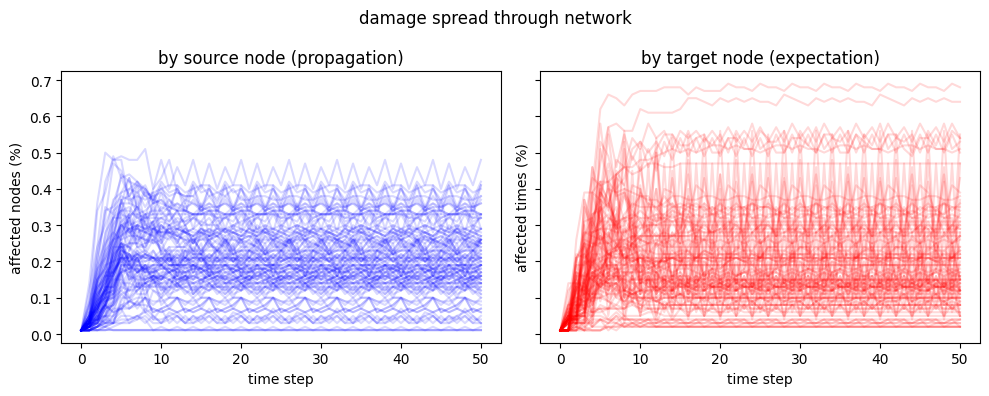

In [10]:
fig, axes = plt.subplots(1, 2, figsize=(10, 4), sharey=True)
axes[0].plot(Xpropag.T, c='blue', alpha=0.15)
axes[1].plot(Xexpect.T, c='red', alpha=0.15)
fig.suptitle('damage spread through network')
axes[0].set(title='by source node (propagation)', xlabel='time step', ylabel='affected nodes (%)')
axes[1].set(title='by target node (expectation)', xlabel='time step', ylabel='affected times (%)')
plt.tight_layout()
plt.show()

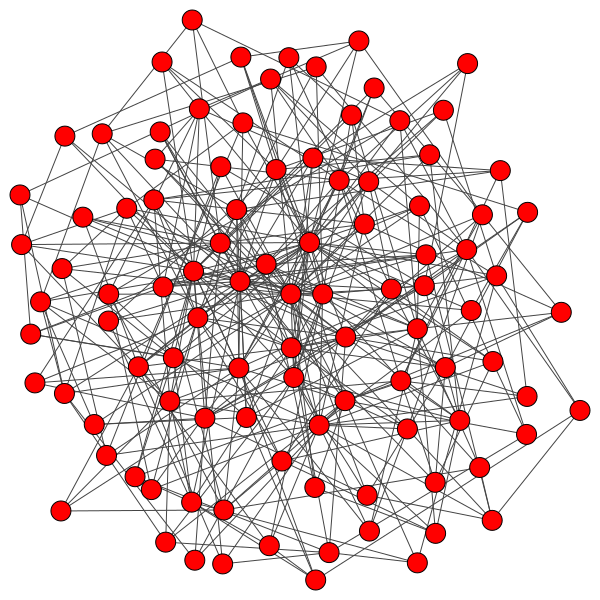

In [17]:
G = datapool.networks.iloc[150]['graph']
G.draw()

In [25]:
stc = datapool.results.loc[(150, 6)].value # 150 = network, 6 = "spanned tree coverage"
stc

[[1, 14, 84, 100],
 [1, 33, 100],
 [1, 26, 94, 100],
 [1, 20, 93, 100],
 [1, 32, 95, 100],
 [1, 16, 91, 100],
 [1, 18, 89, 100],
 [1, 22, 93, 100],
 [1, 17, 84, 100],
 [1, 15, 71, 100],
 [1, 12, 65, 100],
 [1, 16, 85, 100],
 [1, 10, 70, 100],
 [1, 12, 78, 100],
 [1, 15, 78, 100],
 [1, 22, 85, 100],
 [1, 18, 88, 100],
 [1, 10, 81, 100],
 [1, 10, 55, 100],
 [1, 10, 64, 100],
 [1, 9, 63, 100],
 [1, 7, 54, 100],
 [1, 12, 70, 100],
 [1, 10, 49, 100],
 [1, 14, 72, 100],
 [1, 10, 58, 100],
 [1, 8, 51, 99, 100],
 [1, 13, 80, 100],
 [1, 8, 62, 100],
 [1, 7, 67, 100],
 [1, 11, 63, 100],
 [1, 9, 61, 100],
 [1, 6, 47, 100],
 [1, 6, 36, 92, 100],
 [1, 6, 47, 100],
 [1, 9, 70, 100],
 [1, 10, 55, 100],
 [1, 8, 46, 99, 100],
 [1, 7, 63, 100],
 [1, 6, 42, 99, 100],
 [1, 8, 57, 100],
 [1, 7, 69, 100],
 [1, 5, 38, 99, 100],
 [1, 5, 54, 100],
 [1, 6, 57, 100],
 [1, 8, 53, 100],
 [1, 8, 52, 98, 100],
 [1, 5, 47, 100],
 [1, 5, 52, 99, 100],
 [1, 9, 56, 100],
 [1, 9, 46, 99, 100],
 [1, 6, 60, 100],
 [1, 6, 4

In [226]:
T = Xd.shape[-2]
N = Xd.shape[-1]

Xpropag_norm = np.stack([
    x.sum(-1) / np.array(s + (T - len(s))*s[-1:])
    for x, s in zip(Xd, stc)
], 0)
Xpropag_rate = Xpropag_norm[..., 1:] - Xpropag_norm[..., :-1]

Xexpect_norm = np.stack([
    x.sum(-1) / np.array(s + (T - len(s))*s[-1:])
    for x, s in zip(Xd.transpose(2, 1, 0), stc)
], 0)
Xexpect_rate = Xexpect_norm[..., 1:] - Xexpect_norm[..., :-1]

print(Xpropag_norm.shape, Xexpect_norm.shape)
print(Xpropag_rate.shape, Xexpect_rate.shape)

(100, 51) (100, 51)
(100, 50) (100, 50)


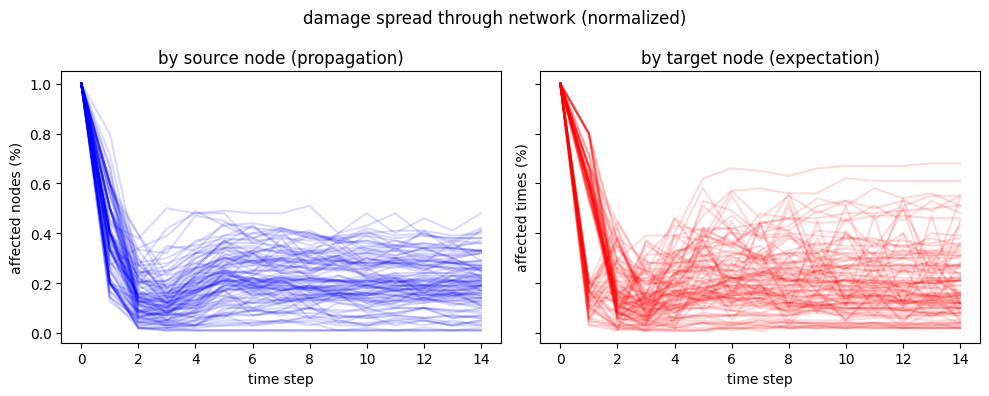

In [227]:
fig, axes = plt.subplots(1, 2, figsize=(10, 4), sharey=True)
axes[0].plot(Xpropag_norm.T[:15], c='blue', alpha=0.15)
axes[1].plot(Xexpect_norm.T[:15], c='red', alpha=0.15)
fig.suptitle('damage spread through network (normalized)')
axes[0].set(title='by source node (propagation)', xlabel='time step', ylabel='affected nodes (%)')
axes[1].set(title='by target node (expectation)', xlabel='time step', ylabel='affected times (%)')
plt.tight_layout()
plt.show()

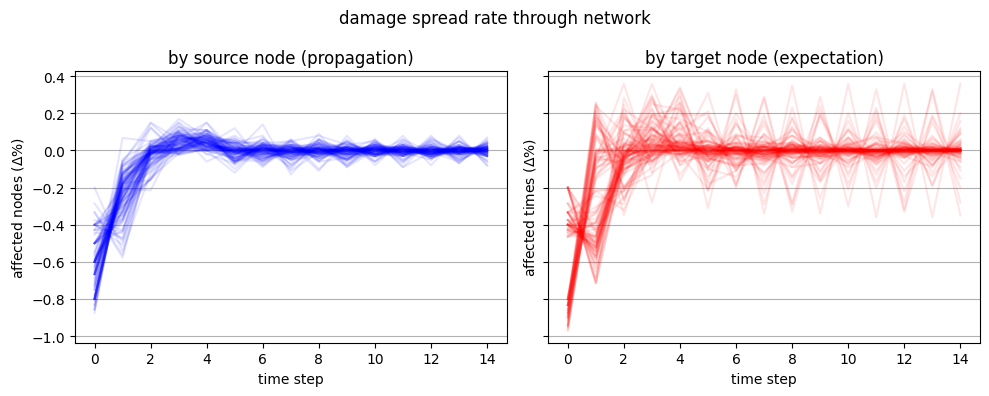

In [228]:
fig, axes = plt.subplots(1, 2, figsize=(10, 4), sharey=True)
axes[0].plot(Xpropag_rate.T[:15], c='blue', alpha=0.1)
axes[1].plot(Xexpect_rate.T[:15], c='red', alpha=0.1)
fig.suptitle('damage spread rate through network')
axes[0].set(title='by source node (propagation)', xlabel='time step', ylabel='affected nodes ($\Delta\%$)')
axes[1].set(title='by target node (expectation)', xlabel='time step', ylabel='affected times ($\Delta\%$)')
axes[0].grid(axis='y')
axes[1].grid(axis='y')
plt.tight_layout()
plt.show()

In [229]:
df = pd.concat([
    pd.DataFrame({
        'time': np.arange(x.shape[-1]),
        'normalized': False, 
        'node role': role, 
        'damage (avg)': np.mean(x, 0),
        'damage (std)': np.std(x, 0),
        'damage (min)': np.min(x, 0),
        'damage (max)': np.max(x, 0),
        'damage (med)': np.median(x, 0)
    })
    for role, x in [('source', Xpropag), ('target', Xexpect)]
] + [
    pd.DataFrame({
        'time': np.arange(x.shape[-1]),
        'normalized': True,
        'node role': role, 
        'damage (avg)': np.mean(x, 0),
        'damage (std)': np.std(x, 0),
        'damage (min)': np.min(x, 0),
        'damage (max)': np.max(x, 0),
        'damage (med)': np.median(x, 0)
    })
    for role, x in [('source', Xpropag_norm), ('target', Xexpect_norm)]
])
df

,time,normalized,node role,damage (avg),damage (std),damage (min),damage (max),damage (med)
0,0,False,source,0.0100,6.938894e-18,0.01,0.01,0.010
1,1,False,source,0.0330,2.211334e-02,0.01,0.14,0.030
2,2,False,source,0.0839,6.607413e-02,0.01,0.36,0.070
3,3,False,source,0.1310,9.275236e-02,0.01,0.50,0.115
4,4,False,source,0.1781,1.098335e-01,0.01,0.49,0.170
...,...,...,...,...,...,...,...,...
46,46,True,target,0.2066,1.512628e-01,0.02,0.68,0.150
47,47,True,target,0.2047,1.413963e-01,0.02,0.68,0.175
48,48,True,target,0.2065,1.518379e-01,0.02,0.67,0.160
49,49,True,target,0.2023,1.440754e-01,0.02,0.69,0.170


The average over time will always sum the first and last axes, so there is need to plot `damage (avg)`. What IS interesting is how the individual values differ, _i.e._ in the matter of standard deviation and median.

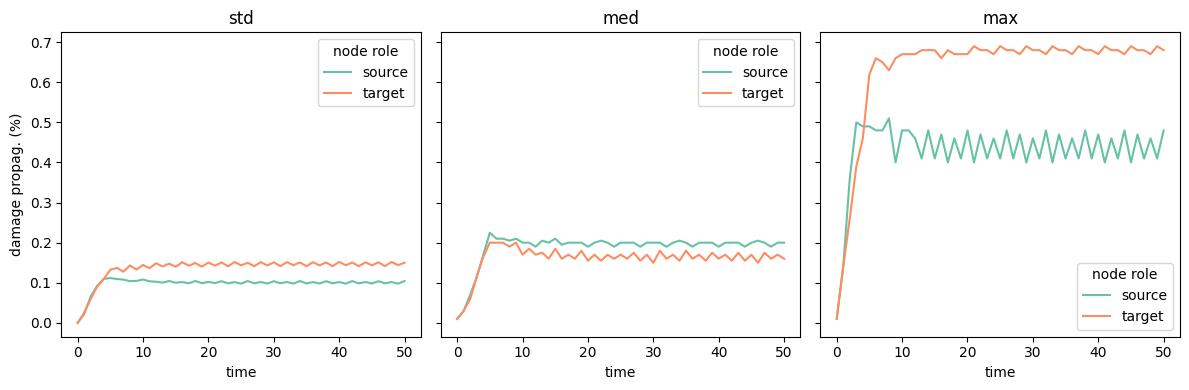

In [55]:
fig, axes = plt.subplots(1, 3, figsize=(4*3, 4), sharey=True)
for ax, y in zip(axes, ['std', 'med', 'max']):
    sns.lineplot(
        df[ ~df['normalized'] ],
        x = 'time',
        y = f'damage ({y})',
        hue = 'node role',
        ax = ax,
    )
    ax.set(ylabel='damage propag. (%)', title=y)
plt.tight_layout()
plt.show()

Another interesting thing to look at is when the normalized and the not normalized curves converge. Here the normalizations refers to not divide the sum by the total amount of nodes in the network, but the amount of nodes that can be reached after each time step.

In another words, we are analizing how the damage propagates in the subgraph defined by all nodes distant at most $t$ hops from the source of the disturb. The opposite is also valid: normalize the damage expectation curve by the number of nodes that could reach it at that time step.

The convergence of the two curves occurs around the average geodesic distance $l$, that is the mean of each pair-wise node distance in the network.

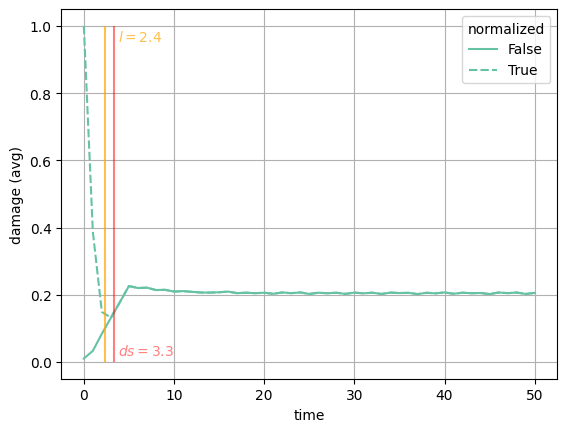

In [230]:
ds = np.mean([ len(s) for s in stc ]) - 1
l = datapool.results.loc[(150, 3)].value # 3 = "average geodesic distance"

sns.lineplot(
    df[ df['node role']=='source' ],
    x = 'time',
    y = 'damage (avg)',
    style = 'normalized',
)

plt.vlines(ds, 0, 1, color='red', alpha=0.5)
plt.text(max([ds, l])+0.5, 0.01, f'$ds = {ds:.1f}$', color='red', alpha=0.5, va='bottom')

plt.vlines(l, 0, 1, color='orange', alpha=0.7)
plt.text(max([ds, l])+0.5, 0.99, f'$l = {l:.1f}$', color='orange', alpha=0.7, va='top')
plt.grid(True)

## 1.2) Looking at multiple initial configurations

Here we will expand the amount of initial configurations, keeping the rule and the network fixed. This is necessary to extract the average behavior of the automaton on that topology.

In [231]:
ntw_id = 150
X_all = dataset[ntw_id]
Xo = X_all[:, 0]        # original trajectory
Xp = X_all[:, 1:]       # perturbed trajectories
Xo.shape, Xp.shape

((5, 51, 100), (5, 100, 51, 100))

In [232]:
Xd = np.stack([ np.abs(Xp[i] - Xo[i]) for i in range(len(Xp)) ])
Xd.shape

(5, 100, 51, 100)

In [233]:
Xpropag = Xd.mean(-1)
Xpropag.shape

(5, 100, 51)

In [234]:
Xexpect = Xd.mean(1).transpose(0, 2, 1)
Xexpect.shape

(5, 100, 51)

In [236]:
T, N = Xd.shape[-2:]
S = np.stack([ np.array(s + (T - len(s))*s[-1:]) for s in stc ], 0)
S.shape

(100, 51)

In [237]:
Xpropag_norm = np.stack([ (x.sum(-1) / S) for x, s in zip(Xd, S) ], 0)
Xexpect_norm = np.stack([ (x.sum(0).T / S) for x, s in zip(Xd, S) ], 0)

Xpropag_norm.shape, Xexpect_norm.shape

((5, 100, 51), (5, 100, 51))

In [238]:
Xpropag_rate = Xpropag_norm[..., 1:] - Xpropag_norm[..., :-1]
Xexpect_rate = Xexpect_norm[..., 1:] - Xexpect_norm[..., :-1]

Xpropag_rate.shape, Xexpect_rate.shape

((5, 100, 50), (5, 100, 50))

Note how the number of rows is increasing fast. We have a total of $N \times C \times T$ rows, beeing:

- $N = 100$ the number of nodes in this selected network;
- $C = 5$ the number of initial configurations;
- $T = 51$ the number of time steps (initial, $t=0$, plus 50 more);

In [244]:
t = np.arange(Xpropag.shape[-1] - 1)

df = pd.DataFrame({ 
    'time_step': [t]*len(Xpropag), 
    'disturb_propag': [ *Xpropag[..., :-1] ], 
    'disturb_expect': [ *Xexpect[..., :-1] ],
    'disturb_propag_rate': [ *Xpropag_rate ], 
    'disturb_expect_rate': [ *Xexpect_rate ], 
})

df = df.explode(['disturb_propag', 'disturb_expect', 'disturb_propag_rate', 'disturb_expect_rate'])
df.reset_index(drop=False, inplace=True, names='init')

df = df.explode(['time_step', 'disturb_propag', 'disturb_expect', 'disturb_propag_rate', 'disturb_expect_rate'])
df.reset_index(drop=False, inplace=True, names='node')
df

,node,init,time_step,disturb_propag,disturb_expect,disturb_propag_rate,disturb_expect_rate
0,0,0,0,0.01,0.01,-0.785714,-0.428571
1,0,0,1,0.03,0.08,-0.130952,-0.464286
2,0,0,2,0.07,0.09,0.016667,-0.037143
3,0,0,3,0.1,0.07,0.08,0.03
4,0,0,4,0.18,0.1,0.02,0.02
...,...,...,...,...,...,...,...
24995,499,4,45,0.28,0.03,0.01,0.0
24996,499,4,46,0.29,0.03,-0.02,0.0
24997,499,4,47,0.27,0.03,0.01,0.0
24998,499,4,48,0.28,0.03,0.0,0.0


Also note how each initial configuration lead to different average behaviors. They have similar shape, converges to distinct percentages. In addition, the overshoot seems to happen often, but not every time.

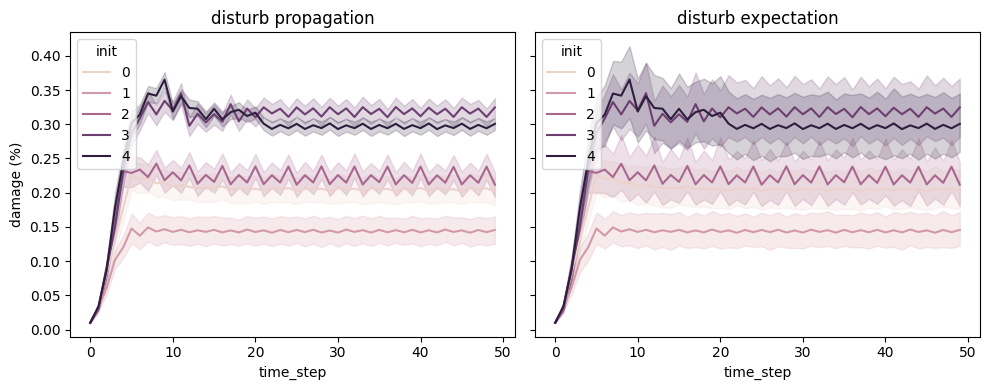

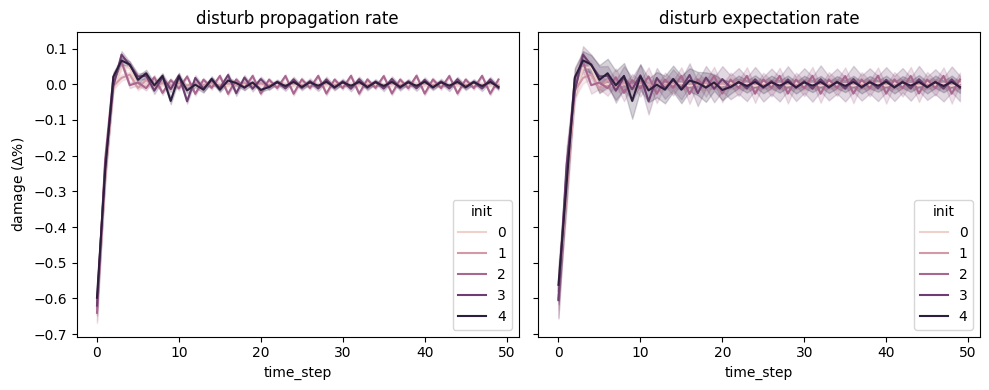

In [247]:
fig, axes = plt.subplots(1, 2, figsize=(5*2, 4), sharey=True)
for ax, y in zip(axes, ['propag', 'expect']):
    sns.lineplot(
        df,
        x = 'time_step',
        y = f'disturb_{y}',
        hue = 'init',
        errorbar = 'ci',
        ax = ax,
    )
    ax.set(ylabel='damage (%)', title=f'disturb {y}ation')
plt.tight_layout()
plt.show()

fig, axes = plt.subplots(1, 2, figsize=(5*2, 4), sharey=True)
for ax, y in zip(axes, ['propag', 'expect']):
    sns.lineplot(
        df,
        x = 'time_step',
        y = f'disturb_{y}_rate',
        hue = 'init',
        errorbar = 'ci',
        ax = ax,
    )
    ax.set(ylabel='damage ($\Delta\%$)', title=f'disturb {y}ation rate')
plt.tight_layout()
plt.show()

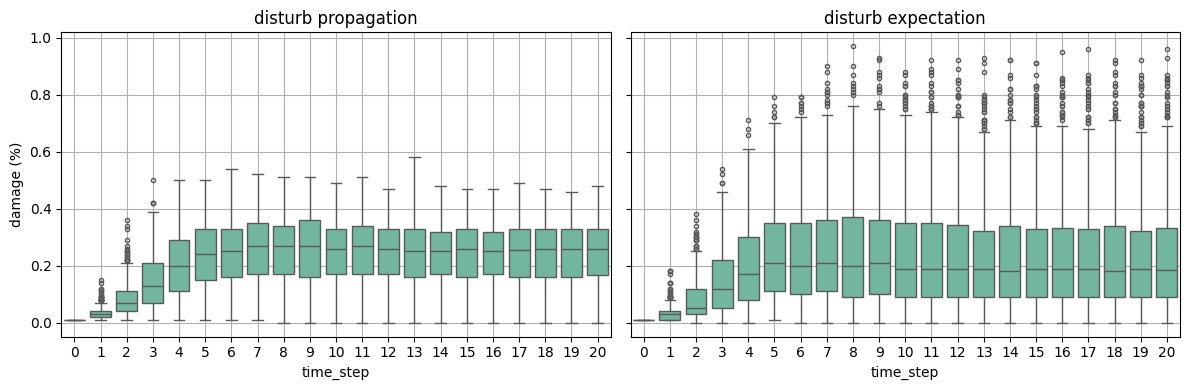

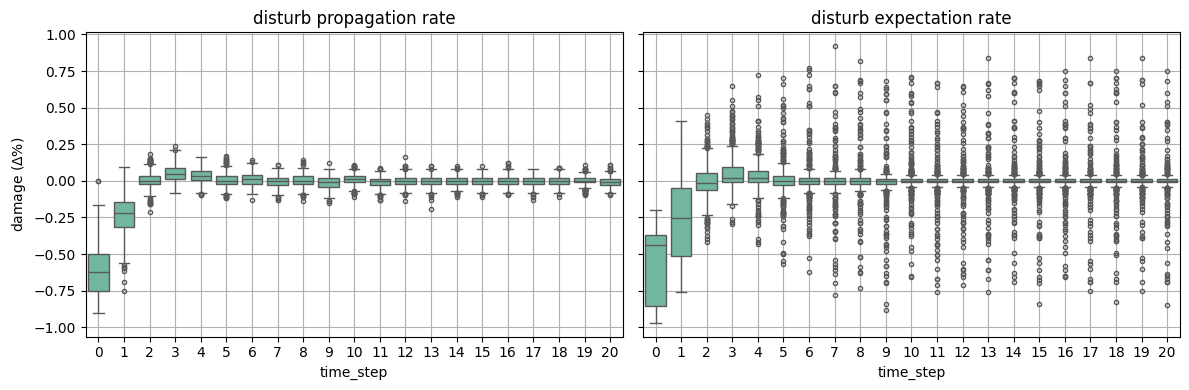

In [249]:
fig, axes = plt.subplots(1, 2, figsize=(6*2, 4), sharey=True)
mask = (df['time_step'] <= 20)
for ax, y in zip(axes, ['propag', 'expect']):
    sns.boxplot(
        df[mask],
        x = 'time_step',
        y = f'disturb_{y}',
        fliersize = 3,
        ax = ax,
    )
    ax.set(ylabel='damage (%)', title=f'disturb {y}ation')
    ax.grid()
plt.tight_layout()
plt.show()


fig, axes = plt.subplots(1, 2, figsize=(6*2, 4), sharey=True)
mask = (df['time_step'] <= 20)
for ax, y in zip(axes, ['propag', 'expect']):
    sns.boxplot(
        df[mask],
        x = 'time_step',
        y = f'disturb_{y}_rate',
        fliersize = 3,
        ax = ax,
    )
    ax.set(ylabel='damage ($\Delta\%$)', title=f'disturb {y}ation rate')
    ax.grid()
plt.tight_layout()
plt.show()

## 1.3) Looking at multiple networks

Now let's look to the behavior of multiple networks and how we can relate them with their structural properties. To simplify, the automaton rule will keep the same and we'll consider only one initial configuration per network again.

To aid in this step, we need to import the tables containing some complex network measures, calculated with the generation of the networks. With these tables, we can generate tabular reports -- node-level or graph-level -- of the applied measures.

In [252]:
datapool.networks

,collection,dataset,label,N,M,K,abbr,graph,source
network_id,,,,,,,,,
0,robustness,toy,BA,50,49,NaN,"BA({'n': 50, 'm': 1, 'power': 1})_1301792788",<containers.GraphAPI object at 0x7f91e2facaf0>,network_000000.txt
1,robustness,toy,BA,50,49,NaN,"BA({'n': 50, 'm': 1, 'power': 1})_799951551",<containers.GraphAPI object at 0x7f91e0190490>,network_000001.txt
2,robustness,toy,BA,50,49,NaN,"BA({'n': 50, 'm': 1, 'power': 1})_2063321439",<containers.GraphAPI object at 0x7f91e0190310>,network_000002.txt
3,robustness,toy,BA,50,49,NaN,"BA({'n': 50, 'm': 1, 'power': 1})_1440823959",<containers.GraphAPI object at 0x7f91e0190d30>,network_000003.txt
4,robustness,toy,BA,50,49,NaN,"BA({'n': 50, 'm': 1, 'power': 1})_700066056",<containers.GraphAPI object at 0x7f91e0190cd0>,network_000004.txt
...,...,...,...,...,...,...,...,...,...
235,robustness,toy,BA,250,990,NaN,"BA({'n': 250, 'm': 4, 'power': 1})_224915926",<containers.GraphAPI object at 0x7f91cc77e0a0>,network_000235.txt
236,robustness,toy,BA,250,990,NaN,"BA({'n': 250, 'm': 4, 'power': 1})_1779759265",<containers.GraphAPI object at 0x7f91cc77e130>,network_000236.txt
237,robustness,toy,BA,250,990,NaN,"BA({'n': 250, 'm': 4, 'power': 1})_1584961966",<containers.GraphAPI object at 0x7f91cc77e1c0>,network_000237.txt


Sometimes, the graph-level measures consist on a statistical moment of node-level measure.

In [253]:
m_mask = (datapool.measures['scope']=='graph')
rep_g = Report.make(datapool, measure_subset=m_mask, header='varname', expand=True, detail=False)
rep_g = pd.merge(datapool.networks[['abbr']], rep_g, on='abbr')
rep_g

,abbr,diam,avg_gdist,effic,hmean_gdist,max_deg,avg_deg,var_deg,skw_deg,krt_deg,avg_cc,avg_bc,cpd,p_deg_enrg,p_deg_entr,q_deg_entr
0,"BA({'n': 50, 'm': 1, 'power': 1})_1301792788",12,4.7344,0.263493,3.795161,8,1.96,2.5584,8.547072,44.942968,0.0,93.86,655.244898,1.056238,1.217547,1.663515
1,"BA({'n': 50, 'm': 1, 'power': 1})_799951551",13,4.7832,0.26638,3.754038,9,1.96,2.9584,12.555072,80.780408,0.0,95.08,745.836735,1.096447,1.251228,1.819857
2,"BA({'n': 50, 'm': 1, 'power': 1})_2063321439",11,4.4368,0.274565,3.642123,10,1.96,2.5584,11.907072,90.600568,0.0,86.42,845.489796,1.035805,1.251861,1.674794
3,"BA({'n': 50, 'm': 1, 'power': 1})_1440823959",7,3.524,0.32165,3.108974,13,1.96,5.6784,53.681472,595.49452,0.0,63.6,926.938776,1.30307,1.065205,1.484478
4,"BA({'n': 50, 'm': 1, 'power': 1})_700066056",8,3.3664,0.33491,2.985873,18,1.96,7.1984,89.863872,1376.069112,0.0,59.66,922.795918,1.411364,1.057209,1.751871
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
235,"BA({'n': 250, 'm': 4, 'power': 1})_224915926",5,2.725504,0.393185,2.543332,56,7.92,42.5376,942.265536,33009.171487,0.173642,216.188,4815.234223,12.134496,2.319957,2.942858
236,"BA({'n': 250, 'm': 4, 'power': 1})_1779759265",4,2.720768,0.393725,2.539842,50,7.92,43.7216,918.189696,29133.277752,0.185811,215.596,3578.925998,12.199054,2.314909,2.994562
237,"BA({'n': 250, 'm': 4, 'power': 1})_1584961966",5,2.76288,0.388615,2.573241,41,7.92,37.4976,687.687936,18881.948191,0.14012,220.86,2874.775399,11.996135,2.330897,2.880221
238,"BA({'n': 250, 'm': 4, 'power': 1})_420171985",4,2.712064,0.395005,2.531611,53,7.92,45.4656,1089.776256,39661.446482,0.154256,214.508,4109.545958,12.217222,2.264026,2.8912


In [254]:
m_mask = (datapool.measures['scope']=='vertex')
rep_v = Report.make(datapool, measure_subset=m_mask, header='varname', expand=True, detail=False)
rep_v = rep_v.reset_index()
rep_v = pd.merge(datapool.networks[['abbr']], rep_v, on='abbr')
rep_v

,abbr,dataset,vertex,stc,deg,qt_tri,cc,bc,pagerank
0,"BA({'n': 50, 'm': 1, 'power': 1})_1301792788",toy,0,"[1, 4, 10, 24, 29, 37, 46, 48, 49, 50]",3,3.0,0.0,140.0,0.029268
1,"BA({'n': 50, 'm': 1, 'power': 1})_1301792788",toy,1,"[1, 7, 23, 29, 37, 46, 48, 49, 50]",6,15.0,0.0,730.0,0.052653
2,"BA({'n': 50, 'm': 1, 'power': 1})_1301792788",toy,2,"[1, 7, 15, 33, 45, 48, 49, 50]",6,15.0,0.0,712.0,0.05432
3,"BA({'n': 50, 'm': 1, 'power': 1})_1301792788",toy,3,"[1, 4, 16, 31, 44, 48, 50]",3,3.0,0.0,615.0,0.027441
4,"BA({'n': 50, 'm': 1, 'power': 1})_1301792788",toy,4,"[1, 7, 13, 24, 29, 37, 46, 48, 49, 50]",6,15.0,0.0,272.0,0.057424
...,...,...,...,...,...,...,...,...,...
31995,"BA({'n': 250, 'm': 4, 'power': 1})_384038923",toy,245,"[1, 5, 63, 232, 250]",4,6.0,0.333333,14.607991,0.002233
31996,"BA({'n': 250, 'm': 4, 'power': 1})_384038923",toy,246,"[1, 5, 45, 214, 250]",4,6.0,0.0,20.773805,0.002278
31997,"BA({'n': 250, 'm': 4, 'power': 1})_384038923",toy,247,"[1, 5, 55, 229, 250]",4,6.0,0.333333,42.002795,0.002319
31998,"BA({'n': 250, 'm': 4, 'power': 1})_384038923",toy,248,"[1, 5, 28, 193, 250]",4,6.0,0.0,17.829913,0.00239


The normal way to handle this data structure is to register a function as a measure in the datapool and apply it to a subset of networks, but as we already have the results stored on disk, we can register the results directly.

Here we'll append the results in the tabular report. Later we'll append them in the datapool itself.

In [255]:
def disturb_diff(ds, init):
    for graph_id, X in enumerate(ds):
        X_all = X[init]
        Xo = X_all[0]
        Xp = X_all[1:]
        Xd = np.abs(Xp - Xo)
        yield (graph_id, Xd)
#

def network_properties(net_id, *reports):
    g_prop = reports[0].loc[net_id]
    g_name = g_prop['abbr']
    n_mask = (reports[1]['abbr'] == g_name)
    n_prop = reports[1][n_mask]
    return g_prop, n_prop
#

df = []
for i, Xpercent in tqdm(disturb_diff(dataset, 0), total=len(dataset)):
    g_prop, n_prop = network_properties(i, rep_g, rep_v)
    for j, x in enumerate(Xpercent):
        df.append(pd.DataFrame({
            'network': i,
            'node': j,
            'time': np.arange(len(x)),
            'amount of disturbed nodes': x.sum(-1),
            'percent of disturbed nodes': x.mean(-1),
            'network diameter': g_prop['diam'],
            'network efficiency': g_prop['effic'],
            'network mean distance': g_prop['avg_gdist'],
            'network mean degree': g_prop['avg_deg'],
            'source node degree': n_prop['deg'].values[j],
            'source node degree (norm)': n_prop['deg'].values[j] / x.shape[-1],
            'source node clustering coef.': n_prop['cc'].values[j] / 2,
        }))
df = pd.concat(df, ignore_index=True)
df

100%|████████████████████████████████████████████████████| 240/240 [00:21<00:00, 11.26it/s]


,network,node,time,amount of disturbed nodes,percent of disturbed nodes,network diameter,network efficiency,network mean distance,network mean degree,source node degree,source node degree (norm),source node clustering coef.
0,0,0,0,1,0.020,12,0.263493,4.734400,1.96,3,0.060,0.0
1,0,0,1,3,0.060,12,0.263493,4.734400,1.96,3,0.060,0.0
2,0,0,2,2,0.040,12,0.263493,4.734400,1.96,3,0.060,0.0
3,0,0,3,1,0.020,12,0.263493,4.734400,1.96,3,0.060,0.0
4,0,0,4,2,0.040,12,0.263493,4.734400,1.96,3,0.060,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...
1631995,239,249,46,12,0.048,5,0.393223,2.726144,7.92,4,0.016,0.0
1631996,239,249,47,16,0.064,5,0.393223,2.726144,7.92,4,0.016,0.0
1631997,239,249,48,12,0.048,5,0.393223,2.726144,7.92,4,0.016,0.0
1631998,239,249,49,17,0.068,5,0.393223,2.726144,7.92,4,0.016,0.0


Before analyzing the disturb progression, it's advised to remove the outliers. Here, considering the network diameter a feature to segment the data, we'll consider only networks whose diameter appears in at least 5 different networks.

In [256]:
diams = rep_g.groupby('diam').count()[['abbr']]
diams

,abbr
diam,
3,11
4,61
5,75
6,23
7,12
8,1
9,6
10,8
11,8


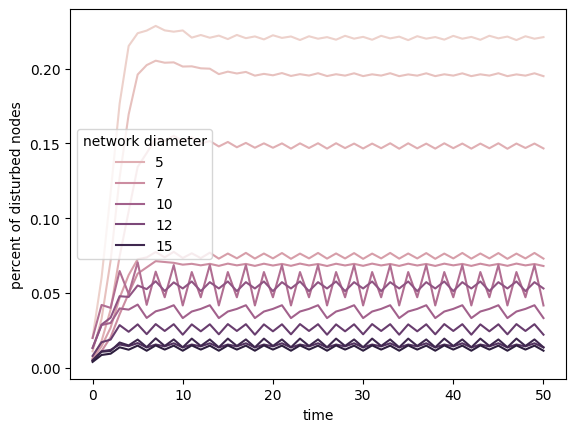

In [257]:
representative = diams[(diams['abbr'] >= 5)].index
mask = (df['network diameter'].isin(representative))
sns.lineplot(
    df[mask],
    x = 'time',
    y = 'percent of disturbed nodes',
    hue = 'network diameter',
    errorbar = None,
)
plt.show()

Now we'll segment by the node clustering coefficient ($cc$). As the $cc$ is not discrete but continuous, another step is required. The values are rounded and grouped into five ranges between 0 and 1.

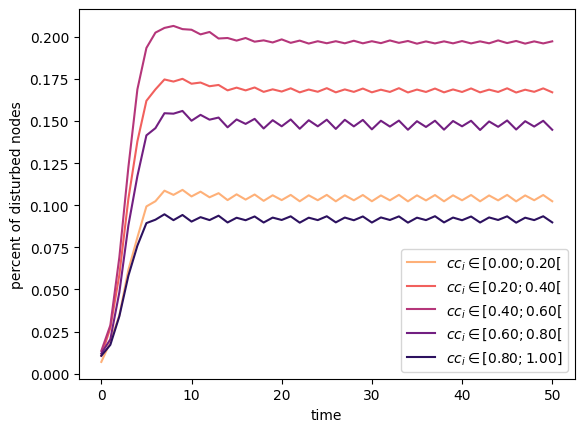

In [259]:
col = 'source node clustering coef.'
cc_min = df[col].min()
cc_max = df[col].max()
step = (cc_max - cc_min) / 5
colors = sns.color_palette('magma_r', 5)
for cc, cl in zip(np.arange(cc_min, cc_max, step), colors):
    if cc+step < cc_max:
        mask = (
            (df[col]>=cc) &
            (df[col]<cc+step)
        )
        sns.lineplot(
            df[mask],
            x = 'time',
            y = 'percent of disturbed nodes',
            errorbar = None,
            label = fr'$cc_i \in [{cc:.2f}; {cc+step:.2f}[$',
            color = cl,
        )
    else:
        mask = (
            (df[col]>=cc) &
            (df[col]<=cc+step)
        )
        sns.lineplot(
            df[mask],
            x = 'time',
            y = 'percent of disturbed nodes',
            errorbar = None,
            label = fr'$cc_i \in [{cc:.2f}; {cc+step:.2f}]$',
            color = cl,
        )

Now we'll take a new measure along the time axis. First, lets take the average of the disturb on the last 10 time steps. This is similar to the steady-state value of the dynamical system represented by the automaton and the network.

In [ ]:
df_aux = df[ df['time']>10 ]
df_aux = df_aux[ [ col for col in df_aux.columns if col != 'time' ] ]
df_aux = df_aux.groupby(['network', 'node']).mean().reset_index()

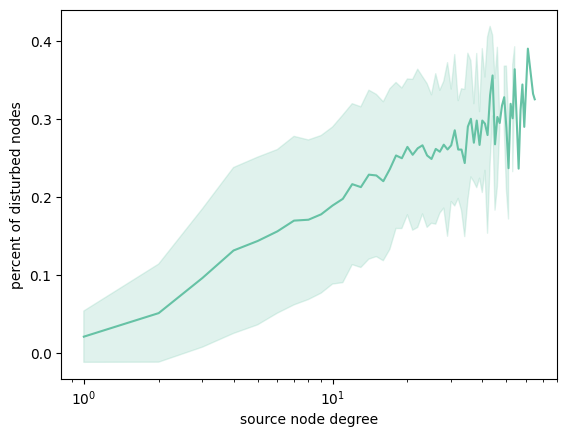

In [261]:
sns.lineplot(
    df_aux,
    x = 'source node degree',
    y = 'percent of disturbed nodes',
    #hue = 'network diameter',
    errorbar = 'sd',
)
plt.xscale('log')

## 1.4) Looking at multiple inits, networks and rules

In [5]:
def kws_with(part, **kwargs):
    keys = list(filter(lambda key: part in key, kwargs.keys()))
    return [ kwargs[k] for k in keys ]

#def peak_time(G, **kwargs):
#    Xd = kws_with('_propag', **kwargs)[0]
#    return np.argmax(Xd, -1)

def steady_state(G, time_window, **kwargs):
    Xpercent = kws_with('llna_', **kwargs)[0]
    return Xpercent[..., -time_window:].mean(-1)

### 1.4.1) Importing and processing the TEPs

Finally, let's consider all the available data. For this we'll take an entire family of LLNA (for instance, $R = 2$), all created networks and their trajectories for all random initial configurations.

First, let's insert all TEPs and its respective automata inside the datapool to make the analysis easier.

**Note:** the values calculated in the next cell blocks will be saved on disk. If you already ran this blocks successfully, just skip to section (1.4.2).

In [266]:
items = os.scandir('../data/teps')

is_compressed = lambda item: ('zip' in item.name or 'tar.xz' in item.name)
is_low_res = lambda item: item.name.startswith('R2B')
is_selected = lambda item: is_compressed(item) and is_low_res(item)

get_names = lambda item: item.name.split('.')[0]
rule_names = sorted(set(map(get_names, filter(is_selected, items))))
rule_names

['R2B0S0',
 'R2B0S1',
 'R2B0S2',
 'R2B0S3',
 'R2B1S0',
 'R2B1S1',
 'R2B1S2',
 'R2B1S3',
 'R2B2S0',
 'R2B2S1',
 'R2B2S2',
 'R2B2S3',
 'R2B3S0',
 'R2B3S1',
 'R2B3S2',
 'R2B3S3']

In [265]:
datapool.load('../data/info', n=True, m=True, r=True)

../data/info/flags.dat loaded in memory
../data/info/networks.dat loaded in memory
../data/info/measures.dat loaded in memory
../data/info/results.dat loaded in memory


Due to the way this data structure works, each automaton is stores as a different "measure", as the intended behavior is to get the report table by the cartesian product of the networks table and the measures table, consolidated by the results table, and then pivot it to expand list-like results (i.e. the ones at node-level).

In [267]:
measures = pd.concat([
    # "defect propagation": the damage spread over time by the node from which the disturbance originated
    pd.DataFrame({
        'name': [ f'rule {nm} defect propagation' for nm in rule_names ],
        'varname': [ f'llna_{nm}_propag' for nm in rule_names ],
        'symbol': [ f'LLNA*(V|{nm})' for nm in rule_names ],
        'scope': 'vertex',
        'function': None,
        'dependence': None,
        'default': None,
        'category': 'defect tracing'
    }),
    # "defect expectation": the chance of being affected by damage regardless of its origin
    pd.DataFrame({
        'name': [ f'rule {nm} defect expectation' for nm in rule_names ],
        'varname': [ f'llna_{nm}_expect' for nm in rule_names ],
        'symbol': [ f'LLNA*(V|{nm})' for nm in rule_names ],
        'scope': 'vertex',
        'function': None,
        'dependence': None,
        'default': None,
        'category': 'defect tracing'
    })
])
datapool.update(m=measures)
datapool.measures.tail()

,name,varname,symbol,scope,category,function,dependence,default
measure_id,,,,,,,,
52,rule R2B2S3 defect expectation,llna_R2B2S3_expect,LLNA*(V|R2B2S3),vertex,defect tracing,None,None,None
53,rule R2B3S0 defect expectation,llna_R2B3S0_expect,LLNA*(V|R2B3S0),vertex,defect tracing,None,None,None
54,rule R2B3S1 defect expectation,llna_R2B3S1_expect,LLNA*(V|R2B3S1),vertex,defect tracing,None,None,None
55,rule R2B3S2 defect expectation,llna_R2B3S2_expect,LLNA*(V|R2B3S2),vertex,defect tracing,None,None,None
56,rule R2B3S3 defect expectation,llna_R2B3S3_expect,LLNA*(V|R2B3S3),vertex,defect tracing,None,None,None


Here we open each dataset and load the aggregated values on memory. It can take some time as the datasets are compressed. To not consume too much memory, the time axis is cutted: only the first `max_t` steps after $t=0$ are taken into account. Also, note how the "dimensions" are permuted (described in the comment lines).

In [269]:
max_t = 30
n_id = datapool.networks.index
m_mask = (
    (datapool.measures['category'] == 'defect tracing') & 
    (datapool.measures['scope'] == 'vertex')
)
qt_half = len(datapool.measures[m_mask]) // 2
m_p = datapool.measures[m_mask][:qt_half] # defect propagation
m_e = datapool.measures[m_mask][qt_half:] # defect expectation

defect_total = lambda X: np.abs(X[1:] - X[0]).astype(np.float32)
defect_propag = lambda X: defect_total(X).mean(-1)
defect_expect = lambda X: defect_total(X).mean(0).T
broadcast = lambda f, *args: np.stack([ f(*args_i) for args_i in zip(*args) ])

for ((id_p, row_p), (id_e, row_e)) in tqdm(zip(m_p.iterrows(), m_e.iterrows()), total=len(rule_names)):
    rname = row_p['varname'].split('_')[1]
    dataset = TEPsDataset(path='../data/teps', rule=rname, defect_freq='single', transform=np.array, cached=False)
    # original shape = (num_inits X num_trajectories X time_steps+1 X num_nodes)
    # adjusted shape = (num_trajectories-1 X num_inits X max_t+1)
    #                = (num_nodes X num_inits X max_t+1)
    results = pd.concat([
        pd.DataFrame({
            'network_id': n_id,
            'measure_id': m_id,
            'value' : [ broadcast(func, teps)[..., :max_t+1].transpose(1, 0, 2) for teps in dataset ],
            'time': 0
        })
        for (m_id, func) in [(id_p, defect_propag), (id_e, defect_expect)]
    ])
    datapool.update(r=results)
    #dataset._is_uncompressed = True
    del dataset

100%|██████████████████████████████████████████████████████| 16/16 [06:36<00:00, 24.77s/it]


In [276]:
datapool.measures.iloc[[31, 47]]

,name,varname,symbol,scope,category,function,dependence,default
measure_id,,,,,,,,
31,rule R2B1S2 defect propagation,llna_R2B1S2_propag,LLNA*(V|R2B1S2),vertex,defect tracing,None,None,None
47,rule R2B1S2 defect expectation,llna_R2B1S2_expect,LLNA*(V|R2B1S2),vertex,defect tracing,None,None,None


In [273]:
Xpropag = datapool.results.loc[(150, 31)].value
Xexpect = datapool.results.loc[(150, 47)].value
print(Xpropag.shape, Xexpect.shape)

(100, 5, 31) (100, 5, 31)


In [278]:
G = datapool.networks.loc[150].graph
stc = datapool.results.loc[(150, 6)].value

In [279]:
T = Xpropag.shape[-1]
N = G.count_nodes()
S = np.stack([ np.array(s + (T - len(s))*s[-1:]) for s in stc ], 0)
S.shape

#Xpropag_norm = np.stack([ (x.sum(-1) / S) for x, s in zip(Xd, S) ], 0)
#Xpropag_rate = Xpropag_norm[..., 1:] - Xpropag_norm[..., :-1]

(100, 31)

In [281]:
measures = pd.concat([
    #pd.DataFrame({
    #    'name': [ f'peak time of rule {nm} defect propag.' for nm in rule_names ],
    #    'varname': [ f'llna_{nm}_tpeak' for nm in rule_names ],
    #    'symbol': [ f'argmax(LLNA*(V|{nm}))' for nm in rule_names ],
    #    'scope': 'vertex',
    #    'function': peak_time,
    #    'dependence': [ [f'rule {nm} defect propagation'] for nm in rule_names ],
    #    'default': None,
    #    'category': 'defect tracing'
    #}),
    pd.DataFrame({
        'name': [ f'steady-state of rule {nm} defect {y}.' for nm in rule_names ],
        'varname': [ f'llna_{nm}_x{y[0]}_steady' for nm in rule_names ],
        'symbol': [ f'LLNA*(V|{nm},t=infty)' for nm in rule_names ],
        'scope': 'vertex',
        'function': steady_state,
        'dependence': [ [f'rule {nm} defect {y}ation'] for nm in rule_names ],
        'default': [{'time_window': 8}] * len(rule_names),
        'category': 'defect tracing'
    })
    for y in ['propag', 'expect']
])

datapool.update(m=measures)
m_mask = (datapool.measures['varname'].isin(measures['varname']))
datapool.update(r=datapool.evaluate(measure_subset=m_mask, log_info=True))

Network 240/240: 100%|█████████████████████| 7680/7680 [00:14<00:00, 513.90it/s]


In [282]:
datapool.save('../data/info/temp', m=True, r=True)

../data/info/temp/flags.dat saved in disk
../data/info/temp/measures.dat saved in disk
../data/info/temp/results.dat saved in disk


### 1.4.2) Creating multi-level tabular reports

In [6]:
datapool.load('../data/info', n=True)
datapool.load('../data/info/temp', m=True, r=True, strict=True)
gc.collect()

../data/info/flags.dat loaded in memory
../data/info/networks.dat loaded in memory
../data/info/temp/measures.dat loaded in memory
../data/info/temp/results.dat loaded in memory


204

Then, let's generate 3 table-like reports with the structural measures at (i) graph-level and (ii) node-level, and (iii) the trajectories of the automata with disturbs. Those tables will be filtered and joined for the next plots.

In [7]:
# get relevant data
m_mask = (datapool.measures['scope']=='graph')
df_ntw = Report.make(datapool, measure_subset=m_mask, header='varname', expand=True, detail=False).infer_objects()
df_ntw.reset_index(drop=False, inplace=True)
del df_ntw['dataset']

# adjust columns
df_ntw.rename(columns={ col: f'ntw_{col}' for col in df_ntw.columns[1:] }, inplace=True)
df_ntw.columns.name = ''
params = df_ntw.apply(lambda row: eval(row['abbr'].split('(')[1].split(')')[0]), axis=1).values
df_aux = pd.DataFrame.from_records(params)
for i, col in enumerate(df_aux.columns[:-1]):
    df_ntw.insert(i+1, f'param_{col}', df_aux[col])

# show a preview
print('shape =', df_ntw.shape)
df_ntw.head()

shape = (240, 18)


,abbr,param_n,param_m,ntw_diam,ntw_avg_gdist,ntw_effic,ntw_hmean_gdist,ntw_max_deg,ntw_avg_deg,ntw_var_deg,ntw_skw_deg,ntw_krt_deg,ntw_avg_cc,ntw_avg_bc,ntw_cpd,ntw_p_deg_enrg,ntw_p_deg_entr,ntw_q_deg_entr
0,"BA({'n': 100, 'm': 1, 'power': 1})_1030348921",100,1,12,5.3088,0.223358,4.477112,9,1.98,2.7596,10.765584,65.894624,0.0,215.94,3499.050505,1.091826,1.296472,1.863004
1,"BA({'n': 100, 'm': 1, 'power': 1})_112366346",100,1,10,4.6358,0.253175,3.949843,17,1.98,5.2396,52.194384,689.202976,0.0,182.29,3706.777778,1.281153,1.157330,1.834840
2,"BA({'n': 100, 'm': 1, 'power': 1})_1144810539",100,1,14,6.0124,0.210254,4.756150,14,1.98,3.6996,24.501984,250.571280,0.0,251.12,3701.898990,1.170811,1.251785,1.913509
3,"BA({'n': 100, 'm': 1, 'power': 1})_1179489287",100,1,10,4.4454,0.260975,3.831786,23,1.98,5.9196,95.855184,1969.334208,0.0,172.77,4087.101010,1.256309,1.226395,1.786584
4,"BA({'n': 100, 'm': 1, 'power': 1})_1355993402",100,1,15,5.8426,0.213959,4.673798,12,1.98,2.7996,14.547984,122.277120,0.0,242.63,3334.717172,1.074294,1.300308,1.843396


In [8]:
# auxiliar table
m_mask = (datapool.measures['scope']=='vertex')
df_aux = Report.make(datapool, measure_subset=m_mask, header='varname', expand=True, detail=False).infer_objects()
df_aux.reset_index(drop=False, inplace=True)
df_aux = df_aux.astype({ 'abbr': 'category' })
df_aux.columns.name = ''

In [10]:
# get relevant data
cols = [ col for col in df_aux.columns if col != 'dataset' and not col.startswith('llna') ]
df_vtx = df_aux[cols].copy()

# adjust columns
df_vtx.rename(columns={ col: f'vtx_{col}' for col in df_vtx.columns[2:] }, inplace=True)
df_vtx['vtx_cc'] = df_vtx['vtx_cc'] / 2 # temporary fix

# show a preview
print('shape =', df_vtx.shape)
df_vtx.head()

shape = (32000, 8)


,abbr,vertex,vtx_stc,vtx_deg,vtx_qt_tri,vtx_cc,vtx_bc,vtx_pagerank
0,"BA({'n': 100, 'm': 1, 'power': 1})_1030348921",0,"[1, 10, 31, 55, 80, 93, 98, 100]",9,36.0,0.0,2616.0,0.038066
1,"BA({'n': 100, 'm': 1, 'power': 1})_1030348921",1,"[1, 8, 34, 71, 89, 97, 100]",7,21.0,0.0,3680.0,0.028916
2,"BA({'n': 100, 'm': 1, 'power': 1})_1030348921",2,"[1, 5, 22, 51, 81, 95, 99, 100]",4,6.0,0.0,2054.0,0.017081
3,"BA({'n': 100, 'm': 1, 'power': 1})_1030348921",3,"[1, 9, 16, 30, 57, 83, 95, 99, 100]",8,28.0,0.0,1502.0,0.035623
4,"BA({'n': 100, 'm': 1, 'power': 1})_1030348921",4,"[1, 9, 20, 43, 75, 89, 97, 100]",8,28.0,0.0,1421.0,0.035792


In [18]:
# get relevant data
m_mask = (datapool.measures['scope']=='vertex')
df_aux = Report.make(datapool, measure_subset=m_mask, header='varname', expand=True, detail=False).infer_objects()
df_aux.reset_index(drop=False, inplace=True)
cols = [ 
    col for col in df_aux.columns 
    if col in ['abbr', 'vertex'] or 
    (col.startswith('llna') and col.endswith('steady'))
]
df_dss = df_aux[cols] # dynamical systems specs

# adjust columns
(num_inits,) = df_dss[ df_dss.columns[3] ].values[0].shape
df_dss.columns.name = ''
df_dss.insert(2, 'init_config', [ list(np.arange(num_inits)) ] * len(df_dss))

df_dss = df_dss.explode([ 
    col for col in df_dss.columns 
    if col.startswith('llna') or col == 'init_config' 
]).astype({ 'init_config': np.short })

# show a preview
print('shape =', df_dss.shape)
df_dss.head()

shape = (160000, 35)


,abbr,vertex,init_config,llna_R2B0S0_xp_steady,llna_R2B0S1_xp_steady,llna_R2B0S2_xp_steady,llna_R2B0S3_xp_steady,llna_R2B1S0_xp_steady,llna_R2B1S1_xp_steady,llna_R2B1S2_xp_steady,...,llna_R2B1S2_xe_steady,llna_R2B1S3_xe_steady,llna_R2B2S0_xe_steady,llna_R2B2S1_xe_steady,llna_R2B2S2_xe_steady,llna_R2B2S3_xe_steady,llna_R2B3S0_xe_steady,llna_R2B3S1_xe_steady,llna_R2B3S2_xe_steady,llna_R2B3S3_xe_steady
0,"BA({'n': 100, 'm': 1, 'power': 1})_1030348921",0,0,0.0,0.0,0.01,0.01,0.03,0.015,0.035,...,0.06,0.06,0.035,0.1,0.025,0.0,0.01,0.11,0.0,0.0
0,"BA({'n': 100, 'm': 1, 'power': 1})_1030348921",0,1,0.0,0.01,0.0,0.01,0.03,0.03,0.1,...,0.12,0.01,0.04,0.21,0.025,0.0,0.01,0.07,0.0,0.0
0,"BA({'n': 100, 'm': 1, 'power': 1})_1030348921",0,2,0.0,0.01,0.0,0.01,0.07,0.015,0.055,...,0.0,0.0,0.0,0.005,0.0,0.0,0.01,0.0,0.07,0.0
0,"BA({'n': 100, 'm': 1, 'power': 1})_1030348921",0,3,0.0,0.04,0.0,0.01,0.0,0.06,0.16,...,0.0,0.01,0.03,0.0,0.04,0.0,0.01,0.01,0.065,0.0
0,"BA({'n': 100, 'm': 1, 'power': 1})_1030348921",0,4,0.0,0.04,0.06,0.01,0.0,0.06,0.205,...,0.0,0.01,0.005,0.0,0.03,0.0,0.01,0.01,0.065,0.0


In [19]:
# creates batches of specified size
def batched(it, size):
    for i in range(0, len(it), size):
        yield it[i:i+size]

In [20]:
# get relevant data
m_mask = (datapool.measures['scope']=='vertex')
df_aux = Report.make(datapool, measure_subset=m_mask, header='varname', expand=True, detail=False).infer_objects()
df_aux.reset_index(drop=False, inplace=True)
cols = [ 
    col for col in df_aux.columns 
    if col in ['abbr', 'vertex'] or 
    (col.startswith('llna') and not col in df_dss.columns)
]
df_trj = df_aux[cols]

# adjust columns
(num_inits, num_steps) = df_trj[ df_trj.columns[3] ].values[0].shape
df_trj.columns.name = ''
df_trj.insert(2, 'init_config', [ list(np.arange(num_inits)) ] * len(df_trj))
df_trj.insert(3, 'time_step', [ list(np.arange(num_steps)) ] * len(df_trj))

df_trj = df_trj.explode([ 
    col for col in df_trj.columns 
    if col.startswith('llna') or col == 'init_config' 
]).astype({ 'init_config': np.short })

# explode by parts to avoid memory overflow
df_list = []
cols = [
    col for col in df_trj.columns 
    if col.endswith('_propag') or col.endswith('_expect') or col == 'time_step' 
]
idx = df_trj.index.unique()

for i in tqdm(batched(idx, 100), total=(len(idx)//100)):
    df_temp = df_trj.loc[i].explode(cols)
    df_temp = df_temp.astype({
        col: (np.float32 if col.startswith('llna') else np.short) 
        for col in cols
    })
    df_list.append(df_temp)
    
df_trj = pd.concat(df_list, ignore_index=True)

# show a preview
print('shape =', df_trj.shape)
df_trj.head()

100%|████████████████████████████████████████████████████| 320/320 [00:26<00:00, 12.13it/s]


shape = (4960000, 36)


,abbr,vertex,init_config,time_step,llna_R2B0S0_propag,llna_R2B0S1_propag,llna_R2B0S2_propag,llna_R2B0S3_propag,llna_R2B1S0_propag,llna_R2B1S1_propag,...,llna_R2B1S2_expect,llna_R2B1S3_expect,llna_R2B2S0_expect,llna_R2B2S1_expect,llna_R2B2S2_expect,llna_R2B2S3_expect,llna_R2B3S0_expect,llna_R2B3S1_expect,llna_R2B3S2_expect,llna_R2B3S3_expect
0,"BA({'n': 100, 'm': 1, 'power': 1})_1030348921",0,0,0,0.01,0.01,0.01,0.01,0.01,0.01,...,0.01,0.01,0.01,0.01,0.01,0.01,0.01,0.01,0.01,0.01
1,"BA({'n': 100, 'm': 1, 'power': 1})_1030348921",0,0,1,0.00,0.00,0.01,0.01,0.02,0.02,...,0.06,0.06,0.06,0.06,0.05,0.05,0.01,0.01,0.00,0.00
2,"BA({'n': 100, 'm': 1, 'power': 1})_1030348921",0,0,2,0.00,0.00,0.01,0.01,0.02,0.02,...,0.06,0.06,0.00,0.06,0.00,0.00,0.01,0.11,0.00,0.00
3,"BA({'n': 100, 'm': 1, 'power': 1})_1030348921",0,0,3,0.00,0.00,0.01,0.01,0.03,0.01,...,0.06,0.06,0.07,0.10,0.05,0.00,0.01,0.11,0.00,0.00
4,"BA({'n': 100, 'm': 1, 'power': 1})_1030348921",0,0,4,0.00,0.00,0.01,0.01,0.03,0.02,...,0.06,0.06,0.00,0.10,0.00,0.00,0.01,0.11,0.00,0.00


In [21]:
for item in df_list:
    del item
del df_list
del df_aux
gc.collect()

0

### 1.4.3) Selecting uncorrelated columns and adjusting the scale

This correlation plot will help choosing the columns to analyze the damage, avoiding unnecessary calculations.

**Note:** the `Spectral` color palette is good to visually distinguish between close values, but it isn't good for publication due to color blindness. The other palette written below (commented) has opposing pros and cons.

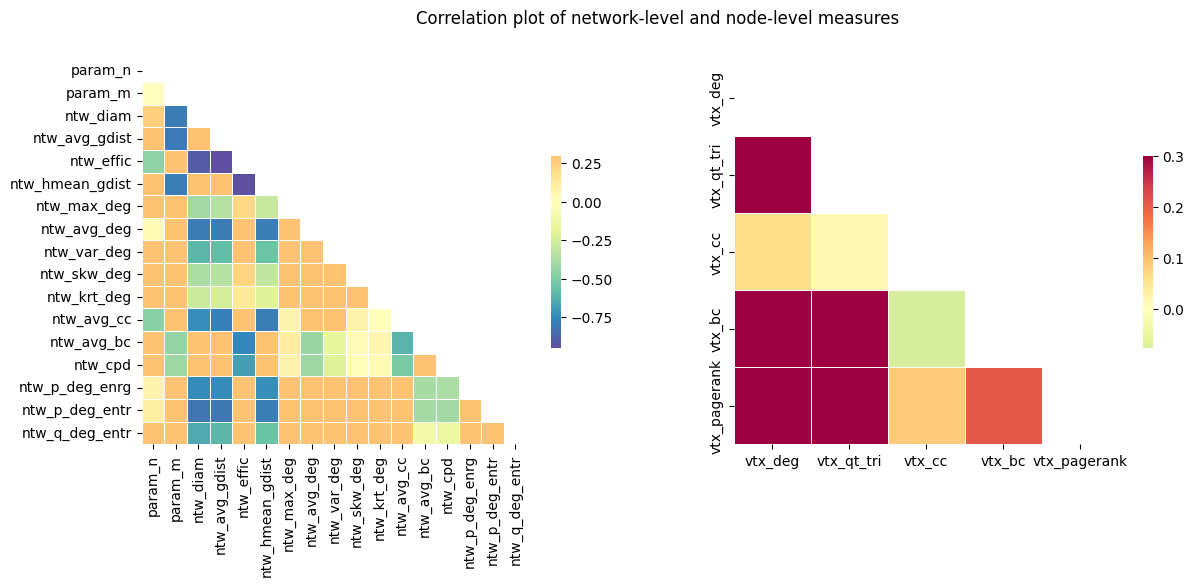

In [10]:
corr_ntw = df_ntw[ df_ntw.columns[1:] ].corr()
corr_vtx = df_vtx[ df_vtx.columns[2:] ].corr()

cmap = 'Spectral_r' #sns.diverging_palette(230, 20, as_cmap=True)
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for ax, corr in zip(axes, [corr_ntw, corr_vtx]):
    mask = np.triu(np.ones_like(corr, dtype=bool))
    sns.heatmap(
        corr, 
        mask = mask, 
        cmap = cmap, 
        vmax = 0.3, 
        center = 0,
        square = True, 
        linewidths = 0.5, 
        cbar_kws = {"shrink": 0.5},
        ax = ax
    )
fig.suptitle('Correlation plot of network-level and node-level measures')
plt.show()

Interesting measures to investigate:

- `ntw_diam`: diameter of the network;
- `ntw_hmean_gdist`: harmonic mean of geodesic distance between nodes (based on node-wise distances);
- `ntw_cpd`: central point dominance (based on betweeness centrality);
- `vtx_bc`: node's betweeness centrality ;
- `vtx_cc`: node's clustering coefficient;
- `vtx_pagerank`: nodes' page rank centrality;

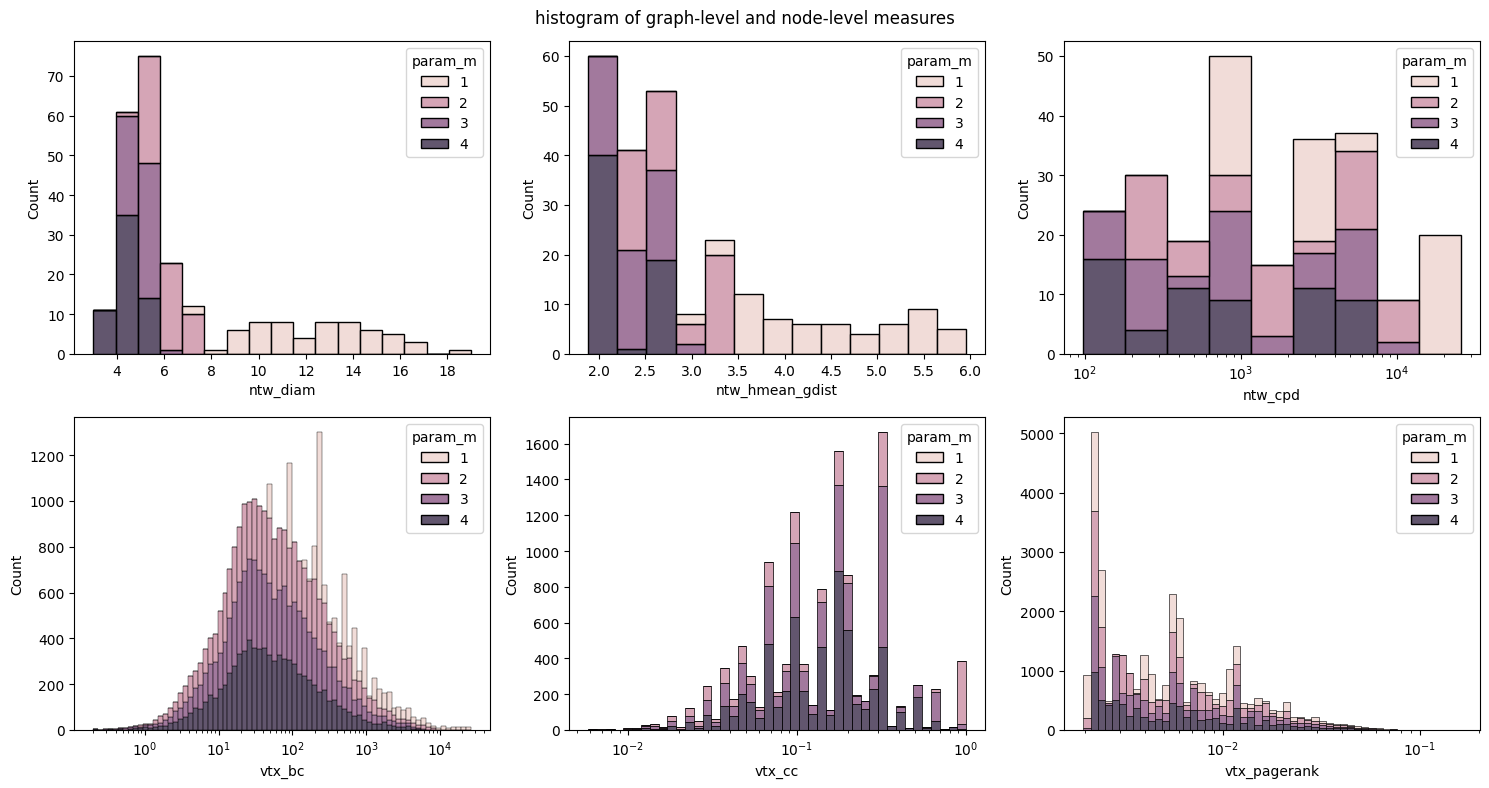

4976

In [11]:
nrows, ncols = (2, 3)
fig, axes = plt.subplots(nrows, ncols, figsize=(5*ncols, 4*nrows))
axes = axes.flatten()
# graph-level measures
for ax_i, col in zip(axes[:2], ['ntw_diam', 'ntw_hmean_gdist']):
    sns.histplot(df_ntw, x=col, hue='param_m', multiple='stack', ax=ax_i)
for ax_i, col in zip(axes[2:3], ['ntw_cpd']):
    sns.histplot(df_ntw, x=col, hue='param_m', multiple='stack', log_scale=10, ax=ax_i)
# node-level measures
df_temp = df_vtx.merge(df_ntw[['abbr', 'param_m']])
for ax_i, col in zip(axes[3:], ['vtx_bc', 'vtx_cc', 'vtx_pagerank']):
    sns.histplot(df_temp, x=col, hue='param_m', multiple='stack', log_scale=10, ax=ax_i)
# exhibition
plt.suptitle('histogram of graph-level and node-level measures')
plt.tight_layout()
plt.show()
# clearing resources
del df_temp
gc.collect()

In [22]:
map_log10 = lambda arr, repl: np.log10(arr.replace(0, repl)).astype(np.float32)

for col in ['ntw_cpd']:
    min_non_zero = df_ntw[ (df_ntw[col]!=0) ][col].min()
    df_ntw[f'{col}_log10'] = map_log10(df_ntw[col], min_non_zero)
    
for col in ['vtx_bc', 'vtx_cc', 'vtx_pagerank']:
    min_non_zero = df_vtx[ (df_vtx[col]!=0) ][col].min()
    df_vtx[f'{col}_log10'] = map_log10(df_vtx[col], min_non_zero)

### 1.4.4) Ploting damage behavior segmented by selected columns

In [23]:
# select the columns present in the dataframe that contains the name parts informed
def filter_columns(df, cols):
    f = lambda item: bool(sum([ c in item for c in cols ]))
    return df[ list(filter(f, df.columns)) ]

# obtain a subset of the data based on the requested columns (main + extra), 
# the minimum amount of graphs/nodes with a given property and a rounding base
def representative_set(dfA, dfB, required, min_qt=5, base=None):
    col = required[0]
    required = ['abbr', 'vertex'] + list(required)
    dfA = filter_columns(dfA, required)
    dfB = filter_columns(dfB, required)
    # round column values to group easier
    if base is not None:
        dfA = dfA.copy()
        dfA[col] = np.ceil(dfA[col] / base) * base
    group = dfA.groupby(col)
    # calculate aggregated metric
    if col.startswith('vtx_'):
        count = group.count()
    elif col.startswith('ntw_') or col.startswith('param_'):
        count = group.nunique()
    else:
        print(col, dfA.columns)
        raise
    # generate subset and mask
    subset = count[(count['abbr'] >= min_qt)].index
    mask = (dfA[col].isin(subset))
    df = dfA[mask].merge(dfB, on=list(set(dfA.columns) & set(dfB.columns)))
    return df, mask, np.array(subset)

In [49]:
def translate(term):
    tr = {
        'time_step': 'time step',
        'propag': 'defect propagation',
        'expect': 'defect expectation',
        #'tpeak': 'peak time of defect propagation',
        'xp_steady': 'steady-state of defect propagation',
        'xe_steady': 'steady-state of defect expectation',
    }
    return tr[term] if term in tr else term

def plot_llna_family(df, res, x='time_step', y='defects', hue=None, share_axis=True, kind='line',
                     preview=False, save_as=None, rmv_log=False, *args, **kwargs):
    num = res**2
    fig, axes = plt.subplots(num, num, figsize=(5*num, 5*num), dpi=100, sharex=share_axis, sharey=share_axis)
    
    # individual plot per rule
    for (i, j) in tqdm(itt.product(range(num), range(num)), total=num**2):
        rule = f'R{res}B{i}S{j}'
        ax = axes[i][j]
        gr = getattr(sns, kind+'plot')(
            df,
            x = x,
            y = f'llna_{rule}_{y}',
            hue = hue,
            ax = ax,
            *args,
            **kwargs,
        )
        ax.set(title=rule, ylabel=translate(y), xlabel=translate(x))
        
        # remove embedded log scale from legend
        if rmv_log and hue is not None and hue.endswith('log10'):
            legend = gr.axes.get_legend()
            legend.set_title(hue.split('_log10')[0])
            for txtbox in legend.texts:
                lbl = eval(txtbox.get_text())
                lbl = np.power(10, lbl).round(decimals=3)
                txtbox.set_text(f'{lbl:.3f}')
                
    # final steps
    plt.tight_layout()
    if save_as is not None:
        fig.savefig(f'pictures/raster/{save_as}.png')
        fig.savefig(f'pictures/vector/{save_as}.pdf')
    if preview:
        fig.set_size_inches(3.5*num, 3.5*num)
        plt.tight_layout()
        plt.show()
    else:
        plt.close()

Below are some plots comparing the structural properties and the disturb propagation along time. Look at the `tests/pictures` folder to see the results. The main conclusion is written in form of comment lines in the code blocks.

**Note:** when plotting graph-level data, using `llna_(...)_propag` or `llna_(...)_expect` time series will give the same results, as both of them will end as an average at both node dimensions (first and last). Only when plotting node-level data that we'll investigate both cases separatedly.

**TO-DO**: study [Seaborn error plots](https://seaborn.pydata.org/tutorial/error_bars.html)

For all of the statistics, we will report the error in two forms: simple mean with confidence interval (ci = 95%), and median with inter-quartile range (pi = 50%). Note that when filtering by network properties, even with a small sample size (i.e. around 10 or 20 samples per group), the dataset will be expanded by the amount of nodes, which ensures a good number of data points per time step to compute the statistics.
- with a minimum of $20$ samples per network group, we will have at least $20 \times 50$ time series to analyze ($50$ is the minimum number of nodes per network).

In [65]:
##========PREVIEW==========================
#
#col = 'vtx_pagerank_log10'
#cols = [col, 'time_step', 'propag', 'expect', 'init_config']
#df, mask, values = representative_set(df_vtx, df_trj, cols, 1000, base=0.1)
#
#print(f'"{col}" : {len(df)} lines ({mask.mean()*100:.2f}%)')
#if not col.endswith('_log10'):
#    print(values)
#else:
#    print(values, '(log 10 scale)')
#    print((10**values).round(3), '(linear scale)')
#    
##========PREVIEW==========================

In [64]:
##========PREVIEW==========================
#
#for y in ['propag', 'expect']:
#    #
#    sns.lineplot(
#        df.sample(frac=0.25),
#        x = 'time_step',
#        y = f'llna_R2B2S1_{y}',
#        hue = col,
#        errorbar = ('pi', 50),
#        estimator = np.median,
#    )
#    plt.show()
#    #
#    sns.lineplot(
#        df.sample(frac=0.25),
#        x = 'time_step',
#        y = f'llna_R2B2S1_{y}',
#        hue = col,
#        errorbar = ('ci', 99),
#        estimator = np.mean,
#    )
#    plt.show()
#    #
#    if col.startswith('ntw_') or col.startswith('param_'):
#        break
#    
##========PREVIEW==========================

**Impact of DIAMETER**

A bigger diameter is related to a lower propagation of damage.

- why are wider networks more resilient?
- does the high connectivity favor the damage propagation?

A high proximity between any pair of nodes means that the damage can spread faster. Wider networks seem to allow the damage to be absorbed and eliminated before exploding.

In [18]:
col = 'ntw_diam'

df, mask, values = representative_set(df_ntw, df_trj, [col, 'time_step', 'propag', 'init_config'], 20)
print(f'"{col}" : {len(df)} lines ({mask.mean()*100:.2f}%)')
print(values)

kwargs = dict(x='time_step', y='propag', res=2, hue=col)
kwargs_err = [
    ('[med+iqr]', dict(errorbar=('pi', 50), estimator=np.median)), 
    ('[avg+ci]', dict(errorbar=('ci', 95), estimator=np.mean)), 
]

for nmerr, kwerr in kwargs_err:
    print(f'\nError plot by {nmerr}:')
    for mode in ['unshared', 'shared']:
        flag = (mode == 'shared')
        name = f'defect_propag-vs-{col}-r2-{mode}_{nmerr}'
        plot_llna_family(df, share_axis=flag, preview=False, save_as=name, **kwargs, **kwerr)

del df
gc.collect()

"ntw_diam" : 3247250 lines (66.25%)
[4, 5, 6]

Error plot by [med+iqr]:


100%|██████████████████████████████████████████████████████| 16/16 [00:27<00:00,  1.74s/it]



Error plot by [avg+ci]:


100%|██████████████████████████████████████████████████████| 16/16 [06:13<00:00, 23.34s/it]


71997

In [66]:
col = 'ntw_diam'

df, mask, values = representative_set(df_ntw, df_dss, [col, 'steady', 'init_config'], 10)
print(f'"{col}" : {len(df)} lines ({mask.mean()*100:.2f}%)')
print(values)

for y in ['xp_steady', 'xe_steady']:
    kwargs = dict(x=col, y=y, res=2, kind='box', fliersize=2)
    for mode in ['unshared']:
        flag = (mode == 'shared')
        name = f'defect_{y}-vs-{col}-r2-{mode}_[box]'
        plot_llna_family(df, share_axis=flag, preview=False, save_as=name, **kwargs)

del df
gc.collect()

"ntw_diam" : 120500 lines (75.83%)
[3 4 5 6 7]


100%|██████████████████████████████████████████████████████| 16/16 [00:16<00:00,  1.02s/it]


341995

<table style='text-align: center;'>
    <caption>Impact of network <u>diameter</u> for LLNA family R=2. First column: progression along time, unshared axes, error bands using average and 95% confidence interval. Second column: steady-state value approximation, unshared axes, box plot with whiskers (IQR).</caption>
    <tr>
        <th colspan=2><center>Defect Propagation</center></th>
    </tr>
    <tr>
        <td><img src="pictures/raster/defect_propag-vs-ntw_diam-r2-unshared_[avg%2Bci].png"></td>
        <td><img src="pictures/raster/defect_xp_steady-vs-ntw_diam-r2-unshared_[box].png"></td>
    </tr>
</table>

**Impact of CENTRAL POINT DOMINANCE**

The curves are very similar to those obtained with the diameter plot. A higher relative dominance of a node as a path to connect any pair of different nodes can be related to wider networks, in the sense that an extremely central node could prevent the small world property. 

In [21]:
col = 'ntw_cpd_log10'

df, mask, values = representative_set(df_ntw, df_trj, [col, 'time_step', 'propag', 'init_config'], 20, base=0.5)
print(f'"{col}" : {len(df)} lines ({mask.mean()*100:.2f}%)')
print(values)

kwargs = dict(x='time_step', y='propag', res=2, hue=col)
kwargs_err = [
    ('[med+iqr]', dict(errorbar=('pi', 50), estimator=np.median)), 
    ('[avg+ci]', dict(errorbar=('ci', 95), estimator=np.mean)), 
]

for nmerr, kwerr in kwargs_err:
    print(f'\nError plot by {nmerr}:')
    for mode in ['unshared', 'shared']:
        flag = (mode == 'shared')
        name = f'defect_propag-vs-{col}-r2-{mode}_{nmerr}'
        plot_llna_family(df, share_axis=flag, preview=False, save_as=name, **kwargs, **kwerr)

del df
gc.collect()

"ntw_cpd_log10" : 4952250 lines (99.58%)
[2.5, 3.0, 3.5, 4.0, 4.5]

Error plot by [med+iqr]:


100%|██████████████████████████████████████████████████████| 16/16 [00:43<00:00,  2.73s/it]



Error plot by [avg+ci]:


100%|██████████████████████████████████████████████████████| 16/16 [09:35<00:00, 35.97s/it]


80493

In [67]:
col = 'ntw_cpd_log10'

df, mask, values = representative_set(df_ntw, df_dss, [col, 'steady', 'init_config'], 20, base=0.5)
print(f'"{col}" : {len(df)} lines ({mask.mean()*100:.2f}%)')
print(values)

for y in ['xp_steady', 'xe_steady']:
    kwargs = dict(x=col, y=y, res=2, kind='box', fliersize=2)
    for mode in ['unshared']:
        flag = (mode == 'shared')
        name = f'defect_{y}-vs-{col}-r2-{mode}_[box]'
        plot_llna_family(df, share_axis=flag, preview=False, save_as=name, **kwargs)

del df
gc.collect()

"ntw_cpd_log10" : 159750 lines (99.58%)
[2.5 3.  3.5 4.  4.5]


100%|██████████████████████████████████████████████████████| 16/16 [00:21<00:00,  1.36s/it]


173365

<table style='text-align: center;'>
    <caption>Impact of network <u>central point dominance</u> for LLNA family R=2. First column: progression along time, unshared axes, error bands using average and 95% confidence interval. Second column: steady-state value approximation, unshared axes, box plot with whiskers (IQR).</caption>
    <tr>
        <th colspan=2><center>Defect Propagation</center></th>
    </tr>
    <tr>
        <td><img src="pictures/raster/defect_propag-vs-ntw_cpd_log10-r2-unshared_[avg%2Bci].png"></td>
        <td><img src="pictures/raster/defect_xp_steady-vs-ntw_cpd_log10-r2-unshared_[box].png"></td>
    </tr>
</table>

**Impact of BETWEENESS CENTRALITY**

About damage propagation, there is no clear relation involving vertex BC. For some rules the most central nodes seems to affect a bigger part of the network on average, but for other rules it's the opposite. Also, the median values almost coincide regardless of the BC value.

But when looking at the expectation of being perturbed, the more central nodes are actually more resilient than the less central ones. It can be related to their neighboring structure: nodes with higher betweeness centrality have a higher degree, meaning that a single disturb in the neighborhood is relatively insignificant. On the other way, nodes with a lower BC and therefore lower degree are more sensible to neighboring disturbs, with the exception of the totally non-central nodes showing unpredictable pattern.

In [31]:
col = 'vtx_bc_log10'
cols_set = [col, 'time_step', 'propag', 'expect', 'init_config']

df, mask, values = representative_set(df_vtx, df_trj, cols_set, 1000, base=0.5)
print(f'"{col}" : {len(df)} lines ({mask.mean()*100:.2f}%)')
print(values)

for y in ['propag', 'expect']:
    print(f'\n>>> {y.upper()}')
    kwargs = dict(x='time_step', y=y, res=2, hue=col)
    kwargs_err = [
        ('[med+iqr]', dict(errorbar=('pi', 50), estimator=np.median)), 
        ('[avg+ci]', dict(errorbar=('ci', 95), estimator=np.mean)), 
    ]
    for nmerr, kwerr in kwargs_err:
        print(f'\nError plot by {nmerr}:')
        for mode in ['unshared', 'shared']:
            flag = (mode == 'shared')
            name = f'defect_{y}-vs-{col}-r2-{mode}_{nmerr}'
            plot_llna_family(df, share_axis=flag, preview=False, save_as=name, **kwargs, **kwerr)

del df
gc.collect()

"vtx_bc_log10" : 4795235 lines (96.68%)
[-0.5, 1.0, 1.5, 2.0, 2.5, 3.0, 3.5]

Error plot by [med+iqr]:


100%|██████████████████████████████████████████████████████| 16/16 [00:44<00:00,  2.80s/it]



Error plot by [avg+ci]:


100%|██████████████████████████████████████████████████████| 16/16 [08:58<00:00, 33.63s/it]


180395

In [68]:
col = 'vtx_bc_log10'
cols_set = [col, 'steady', 'init_config']

df, mask, values = representative_set(df_vtx, df_dss, cols_set, 1000, base=0.5)
print(f'"{col}" : {len(df)} lines ({mask.mean()*100:.2f}%)')
print(values)

for y in ['xp_steady', 'xe_steady']:
    kwargs = dict(x=col, y=y, res=2, kind='box', fliersize=2)
    for mode in ['unshared']:
        flag = (mode == 'shared')
        name = f'defect_{y}-vs-{col}-r2-{mode}_[box]'
        plot_llna_family(df, share_axis=flag, preview=False, save_as=name, **kwargs)

del df
gc.collect()

"vtx_bc_log10" : 154685 lines (96.68%)
[-0.5  1.   1.5  2.   2.5  3.   3.5]


100%|██████████████████████████████████████████████████████| 16/16 [00:21<00:00,  1.36s/it]


458

<Axes: xlabel='vtx_deg', ylabel='vtx_bc'>

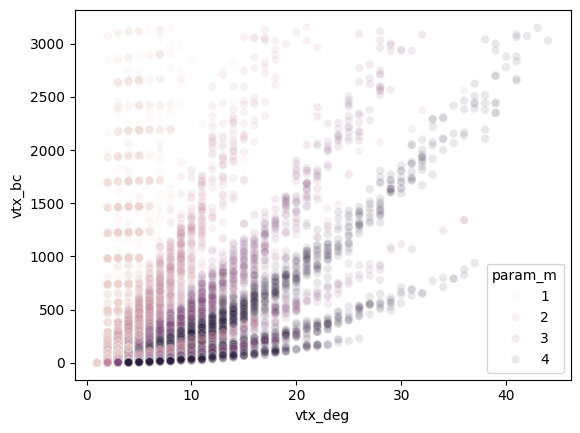

In [56]:
col = 'vtx_bc_log10'
cols_set = [col, 'time_step', 'vtx_bc', 'vtx_deg', 'param_m']
df, mask, values = representative_set(df_vtx, df_ntw, cols_set, 1000, base=0.5)
sns.scatterplot(
    df,
    x = 'vtx_deg',
    y = 'vtx_bc',
    alpha = 0.1,
    hue = 'param_m',
)
del df

<table style='text-align: center;'>
    <caption>Impact of node <u>betweeness centrality</u> for LLNA family R=2. First column: progression along time, unshared axes, error bands using average and 95% confidence interval. Second column: steady-state value approximation, unshared axes, box plot with whiskers (IQR).</caption>
    <tr>
        <th colspan=2><center>Defect Propagation</center></th>
    </tr>
    <tr>
        <td><img src="pictures/raster/defect_propag-vs-vtx_bc_log10-r2-unshared_[avg%2Bci].png"></td>
        <td><img src="pictures/raster/defect_xp_steady-vs-vtx_bc_log10-r2-unshared_[box].png"></td>
    </tr>
    <tr>
        <th colspan=2><center>Defect Expectation</center></th>
    </tr>
    <tr>
        <td><img src="pictures/raster/defect_expect-vs-vtx_bc_log10-r2-unshared_[avg%2Bci].png"></td>
        <td><img src="pictures/raster/defect_xe_steady-vs-vtx_bc_log10-r2-unshared_[box].png"></td>
    </tr>
</table>

**Impact of CLUSTERING COEFFICIENT**

The node CC, at first, does not present any clear pattern about the damage spread through network. But when we look  at the steady-state value of the damage it's possible to see how nodes with non-extreme values of CC are related to more perturbations.

In [129]:
col = 'vtx_cc_log10'
cols_set = [col, 'time_step', 'propag', 'expect', 'init_config']

df, mask, values = representative_set(df_vtx, df_trj, cols_set, 1000, base=0.25)
print(f'"{col}" : {len(df)} lines ({mask.mean()*100:.2f}%)')
print(values, '(log 10 scale)')
print((10**values).round(3), '(linear scale)')

for y in ['propag', 'expect']:
    print(f'\n>>> {y.upper()}')
    kwargs = dict(x='time_step', y=y, res=2, hue=col, rmv_log=True)
    kwargs_err = [
        ('[med+iqr]', dict(errorbar=('pi', 50), estimator=np.median)), 
        ('[avg+ci]', dict(errorbar=('ci', 95), estimator=np.mean)), 
    ]
    for nmerr, kwerr in kwargs_err:
        print(f'\nError plot by {nmerr}:')
        for mode in ['unshared', 'shared']:
            flag = (mode == 'shared')
            name = f'defect_{y}-vs-{col}-r2-{mode}_{nmerr}'
            plot_llna_family(df, share_axis=flag, preview=False, save_as=name, **kwargs, **kwerr)

del df
gc.collect()

"vtx_cc_log10" : 4765630 lines (96.08%)
[-2.   -1.25 -1.   -0.75 -0.5  -0.25] (log 10 scale)
[0.01  0.056 0.1   0.178 0.316 0.562] (linear scale)

>>> PROPAG

Error plot by [med+iqr]:


100%|██████████████████████████████████████████████████████| 16/16 [00:41<00:00,  2.59s/it]



Error plot by [avg+ci]:


100%|██████████████████████████████████████████████████████| 16/16 [09:04<00:00, 34.03s/it]



>>> EXPECT

Error plot by [med+iqr]:


100%|██████████████████████████████████████████████████████| 16/16 [00:42<00:00,  2.68s/it]



Error plot by [avg+ci]:


100%|██████████████████████████████████████████████████████| 16/16 [09:11<00:00, 34.48s/it]


272770

In [69]:
col = 'vtx_cc'
cols_set = [col, 'steady', 'init_config']

df, mask, values = representative_set(df_vtx, df_dss, cols_set, 100, base=0.2)
print(f'"{col}" : {len(df)} lines ({mask.mean()*100:.2f}%)')
print(values)

df[col] = df[col].round(2)

for y in ['xp_steady', 'xe_steady']:
    kwargs = dict(x=col, y=y, res=2, kind='box', fliersize=2)
    for mode in ['unshared']:
        flag = (mode == 'shared')
        name = f'defect_{y}-vs-{col}-r2-{mode}_[box]'
        plot_llna_family(df, share_axis=flag, preview=False, save_as=name, **kwargs)

del df
gc.collect()

"vtx_cc" : 160000 lines (100.00%)
[0.  0.2 0.4 0.6 0.8 1. ]


100%|██████████████████████████████████████████████████████| 16/16 [00:20<00:00,  1.30s/it]


212024

<table style='text-align: center;'>
    <caption>Impact of node <u>clustering coefficient</u> for LLNA family R=2. First column: progression along time, unshared axes, error bands using average and 95% confidence interval. Second column: steady-state value approximation, unshared axes, box plot with whiskers (IQR).</caption>
    <tr>
        <th colspan=2><center>Defect Propagation</center></th>
    </tr>
    <tr>
        <td><img src="pictures/raster/defect_propag-vs-vtx_cc_log10-r2-unshared_[avg%2Bci].png"></td>
        <td><img src="pictures/raster/defect_xp_steady-vs-vtx_cc-r2-unshared_[box].png"></td>
    </tr>
    <tr>
        <th colspan=2><center>Defect Expectation</center></th>
    </tr>
    <tr>
        <td><img src="pictures/raster/defect_expect-vs-vtx_cc_log10-r2-unshared_[avg%2Bci].png"></td>
        <td><img src="pictures/raster/defect_xe_steady-vs-vtx_cc-r2-unshared_[box].png"></td>
    </tr>
</table>

**Impact of PAGE RANK**

For both damage propagation and expectation, the page rank centrality measure is positively correlated. It's better than betweeness centrality to describe the behavior of the damage spread.

In [50]:
col = 'vtx_pagerank_log10'
cols_set = [col, 'time_step', 'propag', 'expect', 'init_config']

df, mask, values = representative_set(df_vtx, df_trj, cols_set, 1000, base=0.2)
print(f'"{col}" : {len(df)} lines ({mask.mean()*100:.2f}%)')
print(values, '(log 10 scale)')
print((10**values).round(3), '(linear scale)')

for y in ['propag', 'expect']:
    print(f'\n>>> {y.upper()}')
    kwargs = dict(x='time_step', y=y, res=2, hue=col, rmv_log=True)
    kwargs_err = [
        ('[med+iqr]', dict(errorbar=('pi', 50), estimator=np.median)), 
        ('[avg+ci]', dict(errorbar=('ci', 95), estimator=np.mean)), 
    ]
    for nmerr, kwerr in kwargs_err:
        print(f'\nError plot by {nmerr}:')
        for mode in ['unshared', 'shared']:
            flag = (mode == 'shared')
            name = f'defect_{y}-vs-{col}-r2-{mode}_{nmerr}'
            plot_llna_family(df, share_axis=flag, preview=False, save_as=name, **kwargs, **kwerr)

del df
gc.collect()

"vtx_pagerank_log10" : 4761910 lines (96.01%)
[-2.6000001 -2.4       -2.2       -2.        -1.8000001 -1.6      ] (log 10 scale)
[0.003 0.004 0.006 0.01  0.016 0.025] (linear scale)

>>> PROPAG

Error plot by [med+iqr]:


100%|██████████████████████████████████████████████████████| 16/16 [00:44<00:00,  2.78s/it]



Error plot by [avg+ci]:


100%|██████████████████████████████████████████████████████| 16/16 [09:03<00:00, 33.99s/it]



>>> EXPECT

Error plot by [med+iqr]:


100%|██████████████████████████████████████████████████████| 16/16 [00:42<00:00,  2.64s/it]



Error plot by [avg+ci]:


100%|██████████████████████████████████████████████████████| 16/16 [08:57<00:00, 33.60s/it]


5431

In [70]:
col = 'vtx_pagerank'
cols_set = [col, 'steady', 'init_config']

df, mask, values = representative_set(df_vtx, df_dss, cols_set, 100, base=0.005)
print(f'"{col}" : {len(df)} lines ({mask.mean()*100:.2f}%)')
print(values)

df[col] = df[col].round(3)

for y in ['xp_steady', 'xe_steady']:
    kwargs = dict(x=col, y=y, res=2, kind='box', fliersize=2)
    for mode in ['unshared']:
        flag = (mode == 'shared')
        name = f'defect_{y}-vs-{col}-r2-{mode}_[box]'
        plot_llna_family(df, share_axis=flag, preview=False, save_as=name, **kwargs)

del df
gc.collect()

"vtx_pagerank" : 158740 lines (99.21%)
[0.005 0.01  0.015 0.02  0.025 0.03  0.035 0.04  0.045]


100%|██████████████████████████████████████████████████████| 16/16 [00:22<00:00,  1.41s/it]


1223

<table style='text-align: center;'>
    <caption>Impact of node <u>page rank</u> for LLNA family R=2. First column: progression along time, unshared axes, error bands using average and 95% confidence interval. Second column: steady-state value approximation, unshared axes, box plot with whiskers (IQR).</caption>
    <tr>
        <th colspan=2><center>Defect Propagation</center></th>
    </tr>
    <tr>
        <td><img src="pictures/raster/defect_propag-vs-vtx_pagerank_log10-r2-unshared_[avg%2Bci].png"></td>
        <td><img src="pictures/raster/defect_xp_steady-vs-vtx_pagerank-r2-unshared_[box].png"></td>
    </tr>
    <tr>
        <th colspan=2><center>Defect Expectation</center></th>
    </tr>
    <tr>
        <td><img src="pictures/raster/defect_expect-vs-vtx_pagerank_log10-r2-unshared_[avg%2Bci].png"></td>
        <td><img src="pictures/raster/defect_xe_steady-vs-vtx_pagerank-r2-unshared_[box].png"></td>
    </tr>
</table>

# 2) Lyapunov Exponent (<span style="color: red; background-color: yellow;">under review</span>)

In [2]:
# `defect_freq="multi"` refers to unitary disturbs along multiple time steps
dataset2 = TEPsDataset(path='../data/teps', rule='R2B1S2', defect_freq='multi', transform=np.array)

100%|████████████████████████████████████████| 150/150 [00:00<00:00, 383.97it/s]


In [3]:
# shape = [num_inits, num_scenarios, time_steps, num_nodes]
# num_scenarios = 1 (original) + N unitary defects (one per node)
dataset[0].shape

(1, 101, 51, 100)

In [4]:
init_conf = 0
X_all = dataset[50][init_conf]
Xo = X_all[0]        # original trajectory
Xp = X_all[1:]       # perturbed trajectories
Xo.shape, Xp.shape

((51, 100), (100, 51, 100))

In [5]:
# the delta at t=0 is the identity
# it will also be the identity for other time steps 
# if dealing with multiple perturbations on time
Xd = np.abs(Xp - Xo) # abs. difference (delta)
Xd[:,0,:]

array([[1, 0, 0, ..., 0, 0, 0],
       [0, 1, 0, ..., 0, 0, 0],
       [0, 0, 1, ..., 0, 0, 0],
       ...,
       [0, 0, 0, ..., 1, 0, 0],
       [0, 0, 0, ..., 0, 1, 0],
       [0, 0, 0, ..., 0, 0, 1]])

In [6]:
# it will also be the identity for other time steps 
# if dealing with multiple perturbations on time
Xd[:,2,:]

array([[1, 1, 0, ..., 0, 0, 0],
       [0, 1, 0, ..., 0, 0, 1],
       [0, 0, 1, ..., 0, 0, 0],
       ...,
       [0, 0, 0, ..., 1, 0, 0],
       [0, 0, 0, ..., 0, 1, 0],
       [0, 1, 0, ..., 0, 0, 1]])

In [7]:
Jt = ((Xp + Xo) % 2).transpose(1, 0, 2)
Jt.shape

(51, 100, 100)

In [8]:
# summing along the time axis is possible to get a notion
# of the size of the tangent vector at each time step
J_sum = Jt.sum((1,2))
J_sum

array([100, 273, 304, 234, 247, 181, 184, 181, 184, 181, 184, 181, 184,
       181, 184, 181, 184, 181, 184, 181, 184, 181, 184, 181, 184, 181,
       184, 181, 184, 181, 184, 181, 184, 181, 184, 181, 184, 181, 184,
       181, 184, 181, 184, 181, 184, 181, 184, 181, 184, 181, 184])

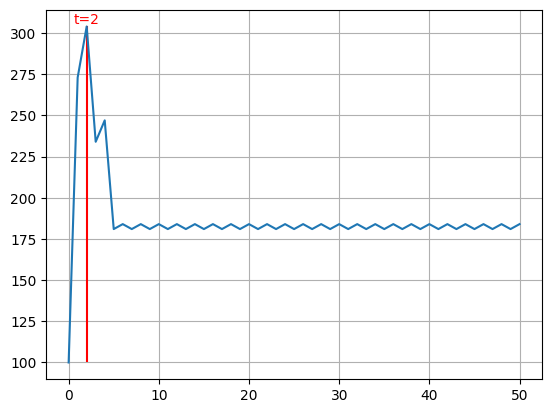

In [9]:
(x, ymin, ymax) = (J_sum.argmax(), J_sum.min(), J_sum.max())
plt.vlines(x, ymin, ymax, color='r')
plt.plot(J_sum)
plt.text(x, ymax+2, f't={x.item()}', ha='center', color='r')
plt.grid()

In [10]:
Jt.shape

(51, 100, 100)

In [11]:
J_all = []
for X_all in dataset:
    X_all = X_all[init_conf]
    Xo = X_all[0]
    Xp = X_all[1:]
    Jt = ((Xo + Xp) % 2).transpose(1, 0, 2)
    J_all.append(Jt)
J_all = np.stack(J_all, 0, dtype=np.float64)
J_all.shape

(150, 51, 100, 100)

In [12]:
J_sum = J_all.sum((-1,-2)) 
J_sum.shape

(150, 51)

In [13]:
J_avg = J_sum.mean(0)
J_std = J_sum.std(0)

(x_peak, y_min, y_max) = (J_avg.argmax(), J_avg.min(), J_avg.max())

x_time = np.arange(J_sum.shape[-1])
y_lower = J_avg - J_std
y_upper = J_avg + J_std

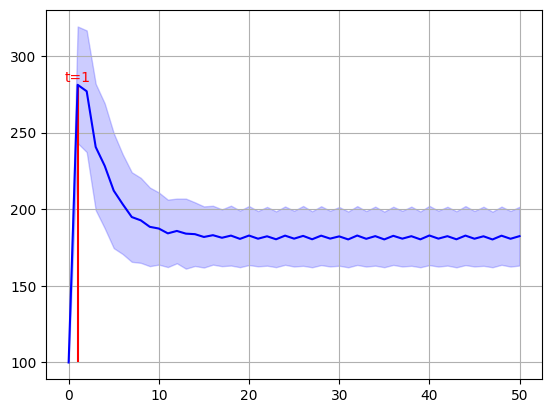

In [14]:
plt.vlines(x_peak, y_min, y_max, color='r')
plt.text(x_peak, y_max+2, f't={x_peak.item()}', ha='center', color='r')

plt.plot(x_time, J_avg, color='b')
plt.fill_between(x_time, y_lower, y_upper, color='b', alpha=0.2)

plt.grid()
plt.show()

In [15]:
T, _, N = Jt.shape
Y0 = np.eye(N)
Yt = [ Y0 ]

for J_tau in Jt:
    Yt.append( np.matmul(J_tau, Yt[-1]) )

Yt = np.stack(Yt, 0)
Yt.shape

(52, 100, 100)

In [16]:
Lt = [ lyapunov_spectrum(Y, t) for t, Y in enumerate(Yt[1:], 1) ]
Lt = np.stack(Lt, 0)
Lt.shape

(51, 100)

In [17]:
X = np.tile(np.arange(1, T+1), (N, 1)).T
X.shape

(51, 100)

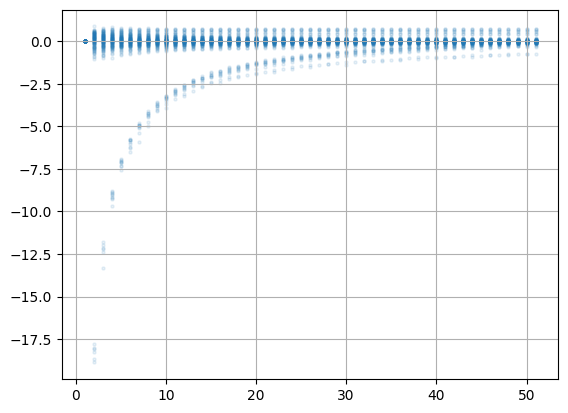

In [18]:
plt.scatter(X, Lt, s=5, alpha=5/T)
plt.grid()

In [19]:
from tqdm import tqdm

In [20]:
J_all.shape

(150, 51, 100, 100)

In [21]:
L_all = []
for J_net in tqdm(J_all, ncols=80):
    T, _, N = J_net.shape
    L = []
    Y = np.eye(N, dtype=np.float64)
    for t, Jt in enumerate(J_net, 0):
        Y = np.matmul(Jt, Y)
        L.append( lyapunov_spectrum(Y, t+1) )
    L_all.append(np.stack(L, 0))
#L_all = np.stack(L_all, -1)
L_all = np.concatenate(L_all, -1)
L_all.shape

100%|█████████████████████████████████████████| 150/150 [00:23<00:00,  6.51it/s]


(51, 15000)

In [22]:
X = np.tile(np.arange(1, L_all.shape[0]+1), (L_all.shape[-1], 1)).T
X.shape

(51, 15000)

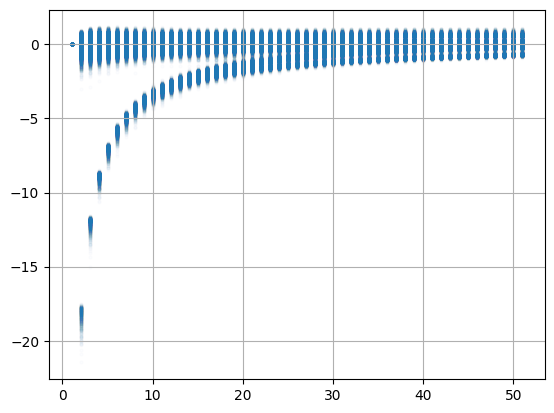

In [23]:
plt.scatter(X, L_all, s=5, alpha=1e-2)
plt.grid()